# Data Cleansing

In [1]:
%pwd

'/mnt/d/OneDrive/MLD01_Article/Code'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import Package

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

## Dataset 2016

In [4]:
%ls PrivateData/Climate-2016/Data/Data/

/bin/bash: /home/linux/anaconda3/envs/tf/lib/libtinfo.so.6: no version information available (required by /bin/bash)
HhldLevel_KeyVariable.dta*  S02_2.dta*  S06.dta*    S08.dta*    S10_3.dta*
PSULevel_KeyVariable.dta*   S03.dta*    S06_4.dta*  S09.dta*    S11.dta*
S01.dta*                    S04.dta*    S07_1.dta*  S10_1.dta*  S12.dta*
S02_1.dta*                  S05.dta*    S07_2.dta*  S10_2.dta*  Weight.dta*


### Meta

In [5]:
df_HhLevel = pd.read_stata("PrivateData/Climate-2016/Data/Data/HhldLevel_KeyVariable.dta")

In [6]:
df_HhLevel

,PSU,HHLD,RespSex,RespAge,RespEdu,Quintl,CZONE
0,101.0,1.0,Female,45-54 Yrs.,Illiterate,Fourth Quintile,Sub-Tropical
1,101.0,2.0,Male,55-64 Yrs.,Primary (1-5),Fifth Quintile (Highest),Sub-Tropical
2,101.0,3.0,Female,45-54 Yrs.,Beginners/Informal edu.,Not Stated,Sub-Tropical
3,101.0,4.0,Male,75+ Yrs.,Beginners/Informal edu.,First Quintile (Lowest),Sub-Tropical
4,101.0,5.0,Male,65-74 Yrs.,Primary (1-5),First Quintile (Lowest),Sub-Tropical
...,...,...,...,...,...,...,...
5055,353.0,16.0,Male,55-64 Yrs.,Bachelor,Third Quintile,Tropical
5056,353.0,17.0,Female,45-54 Yrs.,Illiterate,Fifth Quintile (Highest),Tropical
5057,353.0,18.0,Male,45-54 Yrs.,Illiterate,Fifth Quintile (Highest),Tropical
5058,353.0,19.0,Female,45-54 Yrs.,Illiterate,Third Quintile,Tropical


In [7]:
# Categorical summaries
for col in ["RespSex", "RespAge", "RespEdu", "Quintl", "CZONE"]:
    print(f"\n--- {col} ---")
    print(df_HhLevel[col].value_counts(dropna=False))


--- RespSex ---
RespSex
Male      3396
Female    1664
Name: count, dtype: int64

--- RespAge ---
RespAge
45-54 Yrs.    2083
55-64 Yrs.    1522
65-74 Yrs.    1043
75+ Yrs.       412
Name: count, dtype: int64

--- RespEdu ---
RespEdu
Illiterate                 2199
Beginners/Informal edu.     994
Primary (1-5)               645
Lower Sec.(6-8)             338
SLC                         280
Secondary (9-10)            264
Class 12 / Certificate      160
Bachelor                    121
Master and above             59
Name: count, dtype: int64

--- Quintl ---
Quintl
Third Quintile              996
Fourth Quintile             962
Fifth Quintile (Highest)    958
First Quintile (Lowest)     956
Second Quintile             916
Not Stated                  272
Name: count, dtype: int64

--- CZONE ---
CZONE
Tropical        2705
Sub-Tropical    2038
Temperate        297
Sub-Alpine        20
Name: count, dtype: int64


In [8]:
df_HhLevel.columns

Index(['PSU', 'HHLD', 'RespSex', 'RespAge', 'RespEdu', 'Quintl', 'CZONE'], dtype='object')

In [9]:
df_kept = df_HhLevel[['PSU', 'HHLD', 'Quintl', 'CZONE']]

In [10]:
df_PSULevel = pd.read_stata("PrivateData/Climate-2016/Data/Data/PSULevel_KeyVariable.dta")

In [11]:
df_PSULevel

,PSU,Dist,UrbRur71,Strata,EcoBelt,Comb_Vuln,Comb_Risk,Comb_Adap
0,101.0,Taplejung,Rural,Eastern Mountain,Mountain,High,High,Moderate
1,102.0,Taplejung,Urban,Eastern Mountain,Mountain,High,High,Moderate
2,103.0,Taplejung,Rural,Eastern Mountain,Mountain,High,High,Moderate
3,104.0,Taplejung,Rural,Eastern Mountain,Mountain,High,High,Moderate
4,105.0,Taplejung,Rural,Eastern Mountain,Mountain,High,High,Moderate
...,...,...,...,...,...,...,...,...
248,349.0,Kailali,Rural,Far-Western Tarai,Terai,Low,Low,Moderate
249,350.0,Kailali,Urban,Far-Western Tarai,Terai,Low,Low,Moderate
250,351.0,Kailali,Urban,Far-Western Tarai,Terai,Low,Low,Moderate
251,352.0,Kailali,Rural,Far-Western Tarai,Terai,Low,Low,Moderate


In [12]:
df_PSULevel.columns

Index(['PSU', 'Dist', 'UrbRur71', 'Strata', 'EcoBelt', 'Comb_Vuln',
       'Comb_Risk', 'Comb_Adap'],
      dtype='object')

In [13]:
# Categorical summaries
for col in ['Dist', 'UrbRur71', 'Strata', 'EcoBelt', 'Comb_Vuln', 'Comb_Risk', 'Comb_Adap']:
    print(f"\n--- {col} ---")
    print(df_PSULevel[col].value_counts(dropna=False))


--- Dist ---
Dist
Kathmandu    25
Rupandehi    18
Dang         16
Kailali      14
Dhanusa      14
Rautahat     14
Morang       13
Saptari      13
Achham       12
Dolakha      10
Bajura        9
Salyan        9
Pyuthan       9
Taplejung     9
Dhading       8
Ramechhap     8
Baglung       6
Palpa         6
Panchthar     6
Tanahu        6
Khotang       6
Dhankuta      6
Kaski         6
Jumla         4
Kalikot       4
Mustang       2
Name: count, dtype: int64

--- UrbRur71 ---
UrbRur71
Rural    159
Urban     94
Name: count, dtype: int64

--- Strata ---
Strata
Central Tarai           28
Eastern Tarai           26
Central Hill            24
Western Hill            24
Eastern Hill            18
Western Tarai           18
Mid-Western Hill        18
Kathmandu valley        17
Mid-Western Tarai       16
Far-Western Tarai       14
Far-Western Hill        12
Central Mountain        10
Eastern Mountain         9
Far-Western Mountain     9
Mid-Western Mountain     8
Western Mountain         2
Name:

In [14]:
df_PSULevel.columns

Index(['PSU', 'Dist', 'UrbRur71', 'Strata', 'EcoBelt', 'Comb_Vuln',
       'Comb_Risk', 'Comb_Adap'],
      dtype='object')

In [15]:
df_select = df_PSULevel[['PSU', 'Dist', 'UrbRur71', 'Strata', 'EcoBelt']]

In [16]:
df_kept = df_kept.merge(df_select, on = 'PSU', how='left')

In [17]:
df_kept.head()

,PSU,HHLD,Quintl,CZONE,Dist,UrbRur71,Strata,EcoBelt
0,101.0,1.0,Fourth Quintile,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain
1,101.0,2.0,Fifth Quintile (Highest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain
2,101.0,3.0,Not Stated,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain
3,101.0,4.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain
4,101.0,5.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain


In [18]:
df_kept['Rural_Dummy'] = np.where(df_kept['UrbRur71'] == 'Rural', 1, 0)

### Data Merging

#### Section 01

In [19]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S01.dta", convert_categoricals=False)

In [20]:
df_read.shape

(5060, 17)

In [21]:
df_read

,PSU,HHLD,DIST,VDCMUN,WARD,EA,TOLE,A07NME,A07SEX,A07AGE,A08NME,A08SEX,A08AGE,A09,A10,A11,A12
0,101.0,1.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,51.0,Confidential,2.0,49.0,Confidenti,1.0,17.0,49.0
1,101.0,2.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,55.0,Confidential,1.0,55.0,Confidenti,1.0,5.0,55.0
2,101.0,3.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,46.0,Confidential,2.0,46.0,,13.0,16.0,25.0
3,101.0,4.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,78.0,Confidential,1.0,78.0,Confidenti,10.0,16.0,78.0
4,101.0,5.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,70.0,Confidential,1.0,70.0,Confidenti,10.0,5.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,59.0,Confidential,1.0,59.0,Confidenti,8.0,13.0,37.0
5056,353.0,17.0,0.0,0.0,0.0,0.0,Confidential,Confidential,2.0,52.0,Confidential,2.0,52.0,Confidenti,1.0,17.0,25.0
5057,353.0,18.0,0.0,0.0,0.0,0.0,Confidential,Confidential,1.0,50.0,Confidential,1.0,50.0,Confidenti,7.0,17.0,30.0
5058,353.0,19.0,0.0,0.0,0.0,0.0,Confidential,Confidential,2.0,50.0,Confidential,2.0,50.0,Confidenti,8.0,17.0,25.0


In [22]:
df_read.columns

Index(['PSU', 'HHLD', 'DIST', 'VDCMUN', 'WARD', 'EA', 'TOLE', 'A07NME',
       'A07SEX', 'A07AGE', 'A08NME', 'A08SEX', 'A08AGE', 'A09', 'A10', 'A11',
       'A12'],
      dtype='object')

In [23]:
df_read = df_read[['PSU', 'HHLD', 'A07SEX', 'A07AGE', 'A08SEX', 'A08AGE', 'A11', 'A12']]

In [24]:
df_read.columns = ['PSU', 'HHLD', 'HeadHH_Female', 'HeadHH_Age',
                  'Respon_Female', 'Respon_Age', 'Edu', 'LivingYear']

In [25]:
df_read.loc[:, 'HeadHH_Female'] = df_read.loc[:, 'HeadHH_Female'] - 1
df_read.loc[:, 'Respon_Female'] = df_read.loc[:, 'Respon_Female'] - 1

In [26]:
df_read

,PSU,HHLD,HeadHH_Female,HeadHH_Age,Respon_Female,Respon_Age,Edu,LivingYear
0,101.0,1.0,0.0,51.0,1.0,49.0,17.0,49.0
1,101.0,2.0,0.0,55.0,0.0,55.0,5.0,55.0
2,101.0,3.0,0.0,46.0,1.0,46.0,16.0,25.0
3,101.0,4.0,0.0,78.0,0.0,78.0,16.0,78.0
4,101.0,5.0,0.0,70.0,0.0,70.0,5.0,70.0
...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0.0,59.0,0.0,59.0,13.0,37.0
5056,353.0,17.0,1.0,52.0,1.0,52.0,17.0,25.0
5057,353.0,18.0,0.0,50.0,0.0,50.0,17.0,30.0
5058,353.0,19.0,1.0,50.0,1.0,50.0,17.0,25.0


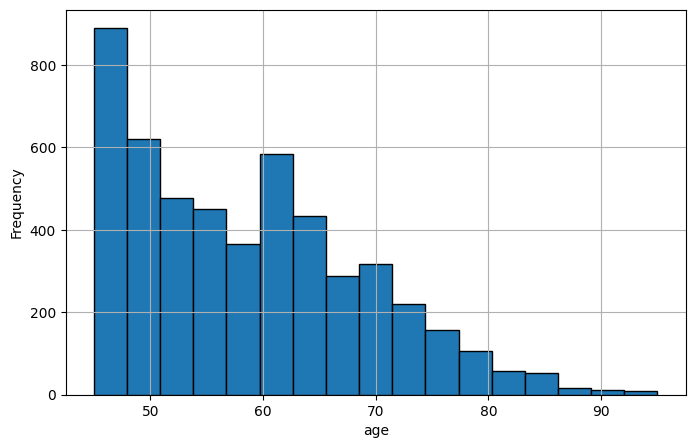

In [27]:
plt.figure(figsize=(8, 5))
df_read["Respon_Age"].hist(bins=17, edgecolor="black")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show()

In [28]:
df_read = df_read.assign(
    Edu_UnderSLC     = np.where(df_read["Edu"] < 12, 1, 0),
    Edu_Certificate  = np.where(df_read["Edu"] == 12, 1, 0),
    Edu_Bachelor     = np.where(df_read["Edu"] == 13, 1, 0),
    Edu_Master       = np.where(df_read["Edu"] == 14, 1, 0),
    Edu_PhD          = np.where(df_read["Edu"] == 15, 1, 0),
    Edu_Literal      = np.where(df_read["Edu"] == 16, 1, 0),
    Edu_Illiterate   = np.where(df_read["Edu"] == 17, 1, 0)
) 

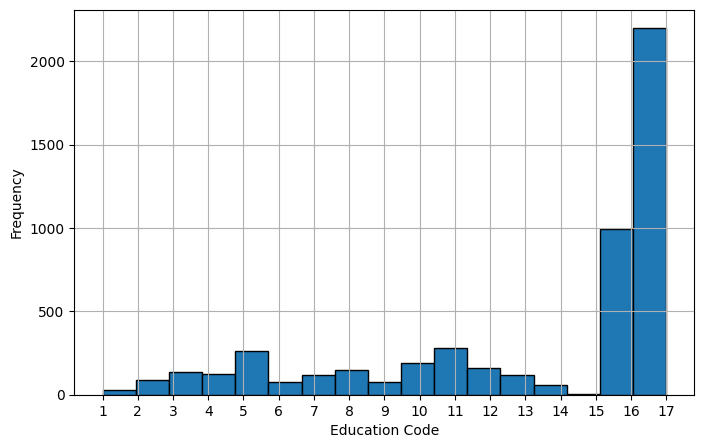

In [29]:
plt.figure(figsize=(8, 5))
df_read["Edu"].hist(bins=17, edgecolor="black")
plt.xlabel("Education Code")
plt.ylabel("Frequency")
plt.xticks(range(1, 18))
plt.show()

In [30]:
df_01 = df_read.copy()

In [31]:
df_01

,PSU,HHLD,HeadHH_Female,HeadHH_Age,Respon_Female,Respon_Age,Edu,LivingYear,Edu_UnderSLC,Edu_Certificate,Edu_Bachelor,Edu_Master,Edu_PhD,Edu_Literal,Edu_Illiterate
0,101.0,1.0,0.0,51.0,1.0,49.0,17.0,49.0,0,0,0,0,0,0,1
1,101.0,2.0,0.0,55.0,0.0,55.0,5.0,55.0,1,0,0,0,0,0,0
2,101.0,3.0,0.0,46.0,1.0,46.0,16.0,25.0,0,0,0,0,0,1,0
3,101.0,4.0,0.0,78.0,0.0,78.0,16.0,78.0,0,0,0,0,0,1,0
4,101.0,5.0,0.0,70.0,0.0,70.0,5.0,70.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0.0,59.0,0.0,59.0,13.0,37.0,0,0,1,0,0,0,0
5056,353.0,17.0,1.0,52.0,1.0,52.0,17.0,25.0,0,0,0,0,0,0,1
5057,353.0,18.0,0.0,50.0,0.0,50.0,17.0,30.0,0,0,0,0,0,0,1
5058,353.0,19.0,1.0,50.0,1.0,50.0,17.0,25.0,0,0,0,0,0,0,1


In [32]:
df_01.columns

Index(['PSU', 'HHLD', 'HeadHH_Female', 'HeadHH_Age', 'Respon_Female',
       'Respon_Age', 'Edu', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate',
       'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal',
       'Edu_Illiterate'],
      dtype='object')

In [33]:
df_select = df_01[['PSU', 'HHLD', 'HeadHH_Female', 'HeadHH_Age', 'Respon_Female',
       'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate',
       'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal',
       'Edu_Illiterate']]

In [34]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [35]:
df_kept.head()

,PSU,HHLD,Quintl,CZONE,Dist,UrbRur71,Strata,EcoBelt,Rural_Dummy,HeadHH_Female,...,Respon_Female,Respon_Age,LivingYear,Edu_UnderSLC,Edu_Certificate,Edu_Bachelor,Edu_Master,Edu_PhD,Edu_Literal,Edu_Illiterate
0,101.0,1.0,Fourth Quintile,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,1.0,49.0,49.0,0,0,0,0,0,0,1
1,101.0,2.0,Fifth Quintile (Highest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.0,55.0,55.0,1,0,0,0,0,0,0
2,101.0,3.0,Not Stated,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,1.0,46.0,25.0,0,0,0,0,0,1,0
3,101.0,4.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.0,78.0,78.0,0,0,0,0,0,1,0
4,101.0,5.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.0,70.0,70.0,1,0,0,0,0,0,0


In [36]:
df_kept.shape

(5060, 21)

#### Section 02-1

In [37]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S02_1.dta")

In [38]:
# Categorical summaries
for col in ['B09OCC']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B09OCC ---
B09OCC
Agriculture                 7313
Student                     4521
NaN                         4085
Household work              3281
Salary/Wage                 2075
Non-Agriculture business    1611
No work                     1190
Unable to work               457
Seeking job                  434
Name: count, dtype: int64


In [39]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S02_1.dta", convert_categoricals=False)

In [40]:
# Categorical summaries
for col in ['B09OCC']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B09OCC ---
B09OCC
1.0    7313
5.0    4521
NaN    4085
4.0    3281
2.0    2075
3.0    1611
7.0    1190
8.0     457
6.0     434
Name: count, dtype: int64


In [41]:
df_read.shape

(24967, 10)

In [42]:
df_read

,PSU,HHLD,B02SN,B03NAME,B04REL,B05SEX,B06AGE,B07EDU,B08MSTS,B09OCC
0,101.0,1.0,1.0,???,1.0,1.0,51.0,11.0,2.0,1.0
1,101.0,1.0,2.0,???,2.0,2.0,49.0,17.0,2.0,1.0
2,101.0,1.0,3.0,???,8.0,2.0,1.0,NaN,NaN,NaN
3,101.0,2.0,1.0,???,1.0,1.0,55.0,5.0,2.0,1.0
4,101.0,2.0,2.0,???,2.0,2.0,50.0,16.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...
24962,353.0,20.0,3.0,???,3.0,2.0,40.0,14.0,2.0,4.0
24963,353.0,20.0,4.0,???,8.0,2.0,20.0,11.0,1.0,5.0
24964,353.0,20.0,5.0,???,8.0,2.0,18.0,12.0,1.0,5.0
24965,353.0,20.0,6.0,???,8.0,1.0,16.0,11.0,1.0,5.0


In [43]:
df_read['Female_Ratio'] = df_read['B05SEX'] - 1
df_read['U18_Ratio'] = np.where(df_read["B06AGE"] < 18, 1, 0)
df_read['A65_Ratio'] = np.where(df_read["B06AGE"] >= 65, 1, 0)

df_read["B07EDU"] = df_read["B07EDU"].fillna(17)
df_read['Edu12_Ratio'] = np.where((df_read["B07EDU"] >= 12)&(df_read["B07EDU"] < 16), 1, 0)
df_read['Literal_Ratio'] = np.where((df_read["B07EDU"] >= 12)&(df_read["B07EDU"] < 17), 1, 0)

df_read["B09OCC"] = df_read["B09OCC"].fillna(7).astype(int)
df_occ_dummies = pd.get_dummies(df_read["B09OCC"], prefix="OCC").astype(int)
df_occ_dummies.columns = ['Occ_Agri', 'Occ_Wage', 'Occ_NonAgriBus', 
                          'Occ_Household', 'Occ_Stu', 'Occ_Hunting',  
                          'Occ_NoJob', 'Occ_Uable']
df_read = pd.concat([df_read, df_occ_dummies], axis=1)

In [44]:
df_read.columns

Index(['PSU', 'HHLD', 'B02SN', 'B03NAME', 'B04REL', 'B05SEX', 'B06AGE',
       'B07EDU', 'B08MSTS', 'B09OCC', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio',
       'Edu12_Ratio', 'Literal_Ratio', 'Occ_Agri', 'Occ_Wage',
       'Occ_NonAgriBus', 'Occ_Household', 'Occ_Stu', 'Occ_Hunting',
       'Occ_NoJob', 'Occ_Uable'],
      dtype='object')

In [45]:
df_select = df_read[['PSU', 'HHLD', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio',
       'Edu12_Ratio', 'Literal_Ratio', 'Occ_Agri', 'Occ_Wage',
       'Occ_NonAgriBus', 'Occ_Household', 'Occ_Stu', 'Occ_Hunting',
       'Occ_NoJob', 'Occ_Uable']]

In [46]:
df_count = df_read.groupby(['PSU', 'HHLD']).count().reset_index()['B02SN']

In [47]:
df_count

0       3
1       7
2       5
3       5
4       8
       ..
5055    5
5056    3
5057    6
5058    3
5059    7
Name: B02SN, Length: 5060, dtype: int64

In [48]:
df_select_ratio = df_select.groupby(['PSU', 'HHLD']).mean().reset_index()

In [49]:
df_select_ratio['Household_memberNum'] = df_count

In [50]:
df_select_ratio

,PSU,HHLD,Female_Ratio,U18_Ratio,A65_Ratio,Edu12_Ratio,Literal_Ratio,Occ_Agri,Occ_Wage,Occ_NonAgriBus,Occ_Household,Occ_Stu,Occ_Hunting,Occ_NoJob,Occ_Uable,Household_memberNum
0,101.0,1.0,0.666667,0.333333,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,0.0,0.333333,0.000000,3
1,101.0,2.0,0.428571,0.142857,0.000000,0.142857,0.285714,0.857143,0.000000,0.000000,0.000000,0.000000,0.0,0.142857,0.000000,7
2,101.0,3.0,0.400000,0.400000,0.000000,0.000000,0.200000,0.400000,0.000000,0.000000,0.000000,0.000000,0.0,0.600000,0.000000,5
3,101.0,4.0,0.200000,0.400000,0.200000,0.000000,0.400000,0.400000,0.000000,0.000000,0.000000,0.200000,0.0,0.400000,0.000000,5
4,101.0,5.0,0.500000,0.250000,0.125000,0.000000,0.125000,0.625000,0.000000,0.000000,0.125000,0.000000,0.0,0.250000,0.000000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0.400000,0.200000,0.000000,0.400000,0.400000,0.200000,0.200000,0.000000,0.400000,0.000000,0.0,0.200000,0.000000,5
5056,353.0,17.0,0.333333,0.000000,0.000000,0.333333,0.333333,0.333333,0.333333,0.333333,0.000000,0.000000,0.0,0.000000,0.000000,3
5057,353.0,18.0,0.333333,0.166667,0.000000,0.333333,0.333333,0.000000,0.000000,0.333333,0.166667,0.333333,0.0,0.000000,0.166667,6
5058,353.0,19.0,0.666667,0.000000,0.000000,0.666667,0.666667,0.333333,0.000000,0.333333,0.333333,0.000000,0.0,0.000000,0.000000,3


In [51]:
df_kept = df_kept.merge(df_select_ratio, on = ['PSU', 'HHLD'], how='left')

In [52]:
df_kept.head()

,PSU,HHLD,Quintl,CZONE,Dist,UrbRur71,Strata,EcoBelt,Rural_Dummy,HeadHH_Female,...,Literal_Ratio,Occ_Agri,Occ_Wage,Occ_NonAgriBus,Occ_Household,Occ_Stu,Occ_Hunting,Occ_NoJob,Occ_Uable,Household_memberNum
0,101.0,1.0,Fourth Quintile,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.000000,0.666667,0.0,0.0,0.000,0.0,0.0,0.333333,0.0,3
1,101.0,2.0,Fifth Quintile (Highest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.285714,0.857143,0.0,0.0,0.000,0.0,0.0,0.142857,0.0,7
2,101.0,3.0,Not Stated,Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.200000,0.400000,0.0,0.0,0.000,0.0,0.0,0.600000,0.0,5
3,101.0,4.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.400000,0.400000,0.0,0.0,0.000,0.2,0.0,0.400000,0.0,5
4,101.0,5.0,First Quintile (Lowest),Sub-Tropical,Taplejung,Rural,Eastern Mountain,Mountain,1,0.0,...,0.125000,0.625000,0.0,0.0,0.125,0.0,0.0,0.250000,0.0,8


In [53]:
df_kept.shape

(5060, 35)

#### Section 02-2

In [54]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S02_2.dta")

In [55]:
# Categorical summaries
for col in ['B12A', 'B12B', 'B12C', 'B13A', 'B13B', 'B13C']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B12A ---
B12A
Piped water               2682
Sallow / deep Tubewell    1483
Inar / Mul                 510
Jar / Tanker               205
Spring water               113
River / stream              54
Others                       8
Rain water                   5
Name: count, dtype: int64

--- B12B ---
B12B
NaN                       3738
Well / spring              503
Sallow / deep Tubewell     191
River / stream             175
Piped water                142
Spring water               121
Jar / Tanker               103
Others                      53
Rain water                  34
Name: count, dtype: int64

--- B12C ---
B12C
NaN                       4992
River / stream              17
Jar / Tanker                15
Well / Spring               11
Others                       9
Piped water                  5
Spring water                 5
Sallow / deep Tubewell       4
Rain water                   2
Name: count, dtype: int64

--- B13A ---
B13A
Firewood                 3543
LP Gas    

In [56]:
# Categorical summaries
for col in ['B17A', 'B17B', 'B17C', 'B17D', 'B17E', 'B17F', 'B17G', 'B17H', 'B17I', 'B17J', 'B17K', 'B17L']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B17A ---
B17A
Radio                    2256
Mobile phone              899
Television                830
Cable/Dish Television     562
None of above             403
Bicycle                    83
Computer                   10
Motorcycle                 10
Telephone                   5
Other vehicle               2
Name: count, dtype: int64

--- B17B ---
B17B
NaN                      1426
Mobile phone             1344
Cable/Dish Television     950
Television                654
Bicycle                   353
Computer                  180
Motorcycle                 52
Telephone                  49
Internet                   32
Other vehicle              14
Refrigerator                4
Motor vehicle               2
Name: count, dtype: int64

--- B17C ---
B17C
NaN                      2730
Mobile phone              834
Bicycle                   369
Computer                  331
Cable/Dish Television     319
Motorcycle                150
Internet                  142
Telephone            

In [57]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S02_2.dta", convert_categoricals=False)

In [58]:
# Categorical summaries
for col in ['B17A', 'B17B', 'B17C', 'B17D', 'B17E', 'B17F', 'B17G', 'B17H', 'B17I', 'B17J', 'B17K', 'B17L']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B17A ---
B17A
1.0     2256
7.0      899
2.0      830
3.0      562
13.0     403
10.0      83
4.0       10
8.0       10
6.0        5
11.0       2
Name: count, dtype: int64

--- B17B ---
B17B
NaN     1426
7.0     1344
3.0      950
2.0      654
10.0     353
4.0      180
8.0       52
6.0       49
5.0       32
11.0      14
12.0       4
9.0        2
Name: count, dtype: int64

--- B17C ---
B17C
NaN     2730
7.0      834
10.0     369
4.0      331
3.0      319
8.0      150
5.0      142
6.0      121
12.0      36
11.0      18
9.0       10
Name: count, dtype: int64

--- B17D ---
B17D
NaN     3550
7.0      343
10.0     286
5.0      279
8.0      196
6.0      150
12.0     113
4.0      112
11.0      19
9.0       12
Name: count, dtype: int64

--- B17E ---
B17E
NaN     4062
7.0      244
6.0      200
10.0     162
8.0      142
12.0     128
5.0       91
11.0      18
9.0       13
Name: count, dtype: int64

--- B17F ---
B17F
NaN     4339
7.0      232
8.0      168
12.0     157
10.0      86
6.0       57
11

In [59]:
df_read.shape

(5060, 32)

In [60]:
df_read

,PSU,HHLD,B01A,B01B,B01C,B10,B11,B12A,B12B,B12C,...,B17E,B17F,B17G,B17H,B17I,B17J,B17K,B17L,B18,C01
0,101.0,1.0,3.0,1.0,4.0,1.0,3.0,1.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,101.0,2.0,7.0,8.0,15.0,1.0,3.0,1.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,101.0,3.0,5.0,0.0,5.0,1.0,3.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
3,101.0,4.0,5.0,0.0,5.0,1.0,3.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
4,101.0,5.0,8.0,0.0,8.0,1.0,3.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,5.0,8.0,13.0,1.0,1.0,1.0,2.0,NaN,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
5056,353.0,17.0,3.0,2.0,5.0,1.0,1.0,1.0,2.0,NaN,...,8.0,10.0,12.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0
5057,353.0,18.0,6.0,0.0,6.0,2.0,1.0,1.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
5058,353.0,19.0,3.0,8.0,11.0,1.0,1.0,1.0,2.0,NaN,...,7.0,8.0,12.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0


In [61]:
cols = ['B17A','B17B','B17C','B17D','B17E','B17F','B17G','B17H','B17I','B17J','B17K','B17L']

df_read["Radio_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["TV_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Cable_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["PC_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Net_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Phone_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Mobile_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Motorbike_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Car_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Bike_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["OtherVehi_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)
df_read["Refrige_dummy"] = (df_read[cols] == 1).any(axis=1).astype(int)

In [62]:
df_read.columns

Index(['PSU', 'HHLD', 'B01A', 'B01B', 'B01C', 'B10', 'B11', 'B12A', 'B12B',
       'B12C', 'B13A', 'B13B', 'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C',
       'B17A', 'B17B', 'B17C', 'B17D', 'B17E', 'B17F', 'B17G', 'B17H', 'B17I',
       'B17J', 'B17K', 'B17L', 'B18', 'C01', 'Radio_dummy', 'TV_dummy',
       'Cable_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy'],
      dtype='object')

In [63]:
df_select = df_read[['PSU', 'HHLD', 'B10', 'B11', 'B12A', 'B12B',
        'B12C', 'B13A', 'B13B', 'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C',
         'B18', 'C01', 'Radio_dummy', 'TV_dummy',
       'Cable_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy']].fillna(0)

In [64]:
df_select.columns = ['PSU', 'HHLD', 'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2',
        'WaterS3', 'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2', 'IncomeS3',
         'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy', 'TV_dummy',
       'Cable_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy']

In [65]:
df_select['Remittance_dummy'] = (df_select['Remittance_dummy'] - 2).abs()
df_select['Have_AgriLand'] = (df_select['Have_AgriLand'] - 2).abs()

In [66]:
df_select

,PSU,HHLD,Own_Resid,Resid_Type,WaterS1,WaterS2,WaterS3,CookFuelS1,CookFuelS2,CookFuelS3,...,Cable_dummy,PC_dummy,Net_dummy,Phone_dummy,Mobile_dummy,Motorbike_dummy,Car_dummy,Bike_dummy,OtherVehi_dummy,Refrige_dummy
0,101.0,1.0,1.0,3.0,1.0,4.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,101.0,2.0,1.0,3.0,1.0,3.0,0.0,1.0,0.0,0.0,...,1,1,1,1,1,1,1,1,1,1
2,101.0,3.0,1.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1,1,1,1,1,1,1,1,1,1
3,101.0,4.0,1.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1,1,1,1,1,1,1,1,1,1
4,101.0,5.0,1.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,1.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5056,353.0,17.0,1.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5057,353.0,18.0,2.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,...,1,1,1,1,1,1,1,1,1,1
5058,353.0,19.0,1.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,...,1,1,1,1,1,1,1,1,1,1


In [67]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [68]:
df_kept.shape

(5060, 62)

#### Section 03 - Complicated Skip

In [69]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S03.dta")

In [70]:
df_read.shape

(23274, 11)

In [71]:
df_read

,PSU,HHLD,C021CODE,C022DESC,C023UNIT,C024_BR,C025_KA,C026_DP,C027_BR,C028_KA,C029_DP
0,101.0,1.0,Land occupied by house and shelter,Land occupied by residenc,Ropani,2.0,0.0,0.0,2.0,0.0,0.0
1,101.0,1.0,Own land cultivate temporarily,Own land cultivate tempor,Ropani,32.0,0.0,0.0,32.0,0.0,0.0
2,101.0,1.0,Own land occupied by pond/wetland,Own land occupied by pond,No such land,NaN,NaN,NaN,NaN,NaN,NaN
3,101.0,1.0,Own land having fruit cultivation,Own land orchard,Ropani,5.0,0.0,0.0,0.0,0.0,0.0
4,101.0,1.0,Other type of own land,Own land others,Ropani,3.0,0.0,0.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
23269,353.0,19.0,Own land cultivate temporarily,Own land cultivate tempor,Bigha,0.0,10.0,0.0,0.0,10.0,0.0
23270,353.0,19.0,Own land occupied by pond/wetland,Own land occupied by pond,No such land,NaN,NaN,NaN,NaN,NaN,NaN
23271,353.0,19.0,Own land having fruit cultivation,Own land orchard,No such land,NaN,NaN,NaN,NaN,NaN,NaN
23272,353.0,19.0,Other type of own land,Own land others,No such land,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
df_read.columns

Index(['PSU', 'HHLD', 'C021CODE', 'C022DESC', 'C023UNIT', 'C024_BR', 'C025_KA',
       'C026_DP', 'C027_BR', 'C028_KA', 'C029_DP'],
      dtype='object')

#### Section 04

**Yes is Yes**

In [73]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S04.dta", convert_categoricals=False)

In [74]:
df_read.shape

(5060, 13)

In [75]:
df_read

,PSU,HHLD,D01,D02,D03,D04,D05,D06,D07,D08,D09,D10,D11
0,101.0,1.0,29.0,1.0,1.0,2.0,2.0,5.0,5.0,5.0,5.0,7.0,2.0
1,101.0,2.0,40.0,1.0,2.0,1.0,2.0,5.0,5.0,5.0,5.0,6.0,2.0
2,101.0,3.0,30.0,1.0,1.0,1.0,2.0,6.0,5.0,5.0,5.0,5.0,2.0
3,101.0,4.0,62.0,2.0,2.0,1.0,2.0,6.0,6.0,4.0,6.0,5.0,2.0
4,101.0,5.0,56.0,2.0,2.0,1.0,2.0,5.0,6.0,5.0,5.0,7.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,28.0,1.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0
5056,353.0,17.0,23.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
5057,353.0,18.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0
5058,353.0,19.0,36.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0


In [76]:
df_read['HouseHead_AgriExpYear'] = df_read["D01"]
df_read['SavingMembership'] = np.where(df_read["D02"] == 1, 1, 0)
df_read['RegularSaving'] = np.where(df_read["D03"] == 1, 1, 0)
df_read['OrgMembership'] = np.where(df_read["D04"] == 1, 1, 0)
df_read['AgriSupport'] = np.where(df_read["D05"] == 1, 1, 0)
df_read['Dist_Road'] = df_read["D06"]
df_read['Dist_HealthCenter'] = df_read["D07"]
df_read['Dist_SecondarySchool'] = df_read["D08"]
df_read['Dist_Market'] = df_read["D09"]
df_read['Dist_AgriSupport'] = df_read["D10"]
df_read['FramMechan'] = np.where(df_read["D11"] == 1, 1, 0)

In [77]:
df_read.columns

Index(['PSU', 'HHLD', 'D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08',
       'D09', 'D10', 'D11', 'HouseHead_AgriExpYear', 'SavingMembership',
       'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road',
       'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan'],
      dtype='object')

In [78]:
df_select = df_read[['PSU', 'HHLD', 'HouseHead_AgriExpYear', 'SavingMembership',
                        'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road',
                        'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
                        'Dist_AgriSupport', 'FramMechan']]

In [79]:
df_select = df_select.fillna(0)

In [80]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [81]:
df_kept.shape

(5060, 73)

#### Section 05

In [82]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S05.dta")

In [83]:
df_read.shape

(5060, 7)

In [84]:
df_read

,PSU,HHLD,E01,E02,E03,E04,E05
0,101.0,1.0,36000.0,22000.0,0.0,110000.0,0.0
1,101.0,2.0,600000.0,25000.0,0.0,500000.0,0.0
2,101.0,3.0,0.0,0.0,0.0,0.0,0.0
3,101.0,4.0,22000.0,11000.0,0.0,0.0,0.0
4,101.0,5.0,32000.0,13000.0,0.0,14000.0,0.0
...,...,...,...,...,...,...,...
5055,353.0,16.0,0.0,0.0,0.0,125000.0,0.0
5056,353.0,17.0,48000.0,0.0,0.0,180000.0,83500.0
5057,353.0,18.0,0.0,0.0,0.0,0.0,2500000.0
5058,353.0,19.0,25000.0,0.0,0.0,94000.0,0.0


In [85]:
df_read['TotalIncome'] = df_read[['E01', 'E02', 'E03', 'E04', 'E05']].sum(axis=1)

In [86]:
df_read.columns = ['PSU', 'HHLD', 'CropIncome', 'LivestockIncome', 'OtherAgriIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome']

In [87]:
df_read = df_read.fillna(0)

In [88]:
df_select = df_read

In [89]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [90]:
df_kept.shape

(5060, 79)

#### Section 06

In [91]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S06.dta")

In [92]:
df_read.shape

(5060, 33)

In [93]:
df_read

,PSU,HHLD,F01,F02,F03,F04A,F04B,F04C,F05A,F05B,...,F09,F10,F111A_MON,F111A_WK,F111B_MON,F111B_WK,F112A_MON,F112A_WK,F112B_MON,F112B_WK
0,101.0,1.0,No,NaN,Yes,Don't know,NaN,NaN,Hailstorm,Land slide,...,No change,No change,Shrawan,Second week,Shrawan,Second week,Magh,Second week,Magh,Second week
1,101.0,2.0,Yes,Radio,Yes,Earthquake,Deforestation,NaN,Flood,Drought,...,Decreased,Decreased,Chaitra,First week,Baishakh,Fourth week,Mangsir,Fourth week,Poush,Third week
2,101.0,3.0,Yes,Radio,Yes,Don't know,NaN,NaN,Land slide,NaN,...,No change,No change,Baishakh,First week,Jestha,Second week,Mangsir,Third week,Mangsir,Fourth week
3,101.0,4.0,No,NaN,Yes,Don't know,NaN,NaN,Land slide,Sporadic rain,...,Decreased,No change,Jestha,First week,Ashar,First week,Mangsir,Fourth week,Mangsir,Fourth week
4,101.0,5.0,No,NaN,Yes,Don't know,NaN,NaN,Land slide,Windstorm,...,No change,No change,Ashar,Third week,Ashar,Third week,Falgun,Fourth week,Falgun,Fourth week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,Yes,Television,Yes,Deforestation,Natural cause,Urbanization,Flood,Inundation,...,Decreased,Decreased,Jestha,Second week,Ashar,Fourth week,Magh,First week,Poush,First week
5056,353.0,17.0,No,NaN,Yes,Deforestation,Natural cause,Urbanization,Flood,Inundation,...,Decreased,Decreased,Jestha,Fourth week,Ashar,Second week,Poush,Third week,Magh,First week
5057,353.0,18.0,Yes,Television,Yes,Deforestation,Urbanization,Human intervention,Flood,Inundation,...,Decreased,Decreased,Ashar,First week,Ashar,Second week,Mangsir,Second week,Magh,Third week
5058,353.0,19.0,No,NaN,Yes,Deforestation,Natural cause,Urbanization,Flood,Inundation,...,Decreased,Decreased,Jestha,Fourth week,Ashar,Second week,Poush,Third week,Magh,First week


In [94]:
df_read.columns

Index(['PSU', 'HHLD', 'F01', 'F02', 'F03', 'F04A', 'F04B', 'F04C', 'F05A',
       'F05B', 'F05C', 'F05D', 'F05E', 'F06', 'F07', 'F081A_MON', 'F081A_WK',
       'F081B_MON', 'F081B_WK', 'F082A_MON', 'F082A_WK', 'F082B_MON',
       'F082B_WK', 'F09', 'F10', 'F111A_MON', 'F111A_WK', 'F111B_MON',
       'F111B_WK', 'F112A_MON', 'F112A_WK', 'F112B_MON', 'F112B_WK'],
      dtype='object')

In [95]:
# Categorical summaries
for col in ['F01', 'F02', 'F03', 'F04A', 'F04B', 'F04C', 'F05A',
       'F05B', 'F05C', 'F05D', 'F05E', 'F06', 'F07', 'F09', 'F10']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- F01 ---
F01
No     2570
Yes    2490
Name: count, dtype: int64

--- F02 ---
F02
NaN                           2570
Radio                          924
Television                     854
Neighbor / friends             372
Awareness campaign             132
News paper                     124
Family member                   42
Local bodies / authorities      31
Others                          11
Name: count, dtype: int64

--- F03 ---
F03
Yes    4823
No      237
Name: count, dtype: int64

--- F04A ---
F04A
Deforestation          2393
Natural cause           674
Don't know              495
Urbanization            470
Human  intervention     278
NaN                     237
Industrialization       220
God's wish              188
Others                   54
Earthquake               51
Name: count, dtype: int64

--- F04B ---
F04B
NaN                    1364
Natural cause           940
Urbanization            772
Industrialization       629
Human  intervention     612
Deforestation           

In [96]:
df_read['HeardClimate_Dummy'] = np.where(df_read['F01'] == 'Yes', 1, 0)
df_read['ClimateChanged_Dummy'] = np.where(df_read['F03'] == 'Yes', 1, 0)

In [97]:
f02_dummies = pd.get_dummies(df_read["F02"], prefix="ClimateInfo").astype(int)

In [98]:
f02_dummies.columns = [name[:17] for name in f02_dummies.columns]

In [99]:
df_read = pd.concat([df_read, f02_dummies], axis=1)

In [100]:
f04a_dummies = pd.get_dummies(df_read["F04A"], prefix="ClimateReasonA").astype(int)

In [101]:
f04a_dummies.columns = [name[:20] for name in f04a_dummies.columns]

In [102]:
df_read = pd.concat([df_read, f04a_dummies], axis=1)

In [103]:
f04b_dummies = pd.get_dummies(df_read["F04B"], prefix="ClimateReasonB").astype(int)

In [104]:
f04b_dummies.columns = [name[:20] for name in f04b_dummies.columns]

In [105]:
df_read = pd.concat([df_read, f04b_dummies], axis=1)

In [106]:
f04c_dummies = pd.get_dummies(df_read["F04C"], prefix="ClimateReasonC").astype(int)

In [107]:
f04c_dummies.columns = [name[:20] for name in f04c_dummies.columns]

In [108]:
df_read = pd.concat([df_read, f04c_dummies], axis=1)

In [109]:
df_read['SummerTemp_IncreaseDummy'] = np.where(df_read['F06'] == 'Increase', 1, 0)
df_read['SummerTemp_DecreaseDummy'] = np.where(df_read['F06'] == 'Decrease', 1, 0)
df_read['WinterTemp_IncreaseDummy'] = np.where(df_read['F07'] == 'Increase', 1, 0)
df_read['WinterTemp_DecreaseDummy'] = np.where(df_read['F07'] == 'Decrease', 1, 0)

In [110]:
df_read['MonsoonPreci_IncreaseDummy'] = np.where(df_read['F09'] == 'Increase', 1, 0)
df_read['MonsoonPreci_DecreaseDummy'] = np.where(df_read['F09'] == 'Decrease', 1, 0)
df_read['WinterPreci_IncreaseDummy'] = np.where(df_read['F10'] == 'Increase', 1, 0)
df_read['WinterPreci_DecreaseDummy'] = np.where(df_read['F10'] == 'Decrease', 1, 0)

In [111]:
df_read.columns = [name.replace( '\'' ,'x') for name in df_read.columns]

In [112]:
df_read.columns

Index(['PSU', 'HHLD', 'F01', 'F02', 'F03', 'F04A', 'F04B', 'F04C', 'F05A',
       'F05B', 'F05C', 'F05D', 'F05E', 'F06', 'F07', 'F081A_MON', 'F081A_WK',
       'F081B_MON', 'F081B_WK', 'F082A_MON', 'F082A_WK', 'F082B_MON',
       'F082B_WK', 'F09', 'F10', 'F111A_MON', 'F111A_WK', 'F111B_MON',
       'F111B_WK', 'F112A_MON', 'F112A_WK', 'F112B_MON', 'F112B_WK',
       'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInfo_Radio',
       'ClimateInfo_Telev', 'ClimateInfo_News ', 'ClimateInfo_Aware',
       'ClimateInfo_Local', 'ClimateInfo_Neigh', 'ClimateInfo_Famil',
       'ClimateInfo_Other', 'ClimateReasonA_Defor', 'ClimateReasonA_Natur',
       'ClimateReasonA_Indus', 'ClimateReasonA_Urban', 'ClimateReasonA_Human',
       'ClimateReasonA_Godxs', 'ClimateReasonA_Earth', 'ClimateReasonA_Other',
       'ClimateReasonA_Donxt', 'ClimateReasonB_Defor', 'ClimateReasonB_Natur',
       'ClimateReasonB_Indus', 'ClimateReasonB_Urban', 'ClimateReasonB_Human',
       'ClimateReasonB_Godxs', 

In [113]:
df_select = df_read[['PSU', 'HHLD', 'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInfo_Radio',
       'ClimateInfo_Telev', 'ClimateInfo_News ', 'ClimateInfo_Aware',
       'ClimateInfo_Local', 'ClimateInfo_Neigh', 'ClimateInfo_Famil',
       'ClimateInfo_Other', 'ClimateReasonA_Defor', 'ClimateReasonA_Natur',
       'ClimateReasonA_Indus', 'ClimateReasonA_Urban', 'ClimateReasonA_Human',
       'ClimateReasonA_Godxs', 'ClimateReasonA_Earth', 'ClimateReasonA_Other',
       'ClimateReasonA_Donxt', 'ClimateReasonB_Defor', 'ClimateReasonB_Natur',
       'ClimateReasonB_Indus', 'ClimateReasonB_Urban', 'ClimateReasonB_Human',
       'ClimateReasonB_Godxs', 'ClimateReasonB_Earth', 'ClimateReasonB_Other',
       'ClimateReasonC_Defor', 'ClimateReasonC_Natur', 'ClimateReasonC_Indus',
       'ClimateReasonC_Urban', 'ClimateReasonC_Human', 'ClimateReasonC_Godxs',
       'ClimateReasonC_Earth', 'ClimateReasonC_Other',
       'SummerTemp_IncreaseDummy', 'SummerTemp_DecreaseDummy',
       'WinterTemp_IncreaseDummy', 'WinterTemp_DecreaseDummy',
       'MonsoonPreci_IncreaseDummy', 'MonsoonPreci_DecreaseDummy',
       'WinterPreci_IncreaseDummy', 'WinterPreci_DecreaseDummy']]

In [114]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [115]:
df_kept.shape

(5060, 122)

#### Section 06-4

In [116]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S06_4.dta",
                       convert_categoricals=False)

In [117]:
df_read.shape

(96140, 10)

In [118]:
df_read

,PSU,HHLD,F12CODE,F13DESC,F14,F15,F16,F17A,F17B,F17C
0,101.0,1.0,1.0,1. Drought,2.0,NaN,NaN,NaN,NaN,NaN
1,101.0,1.0,2.0,2. Fire in forest,2.0,NaN,NaN,NaN,NaN,NaN
2,101.0,1.0,3.0,3. Fire in shettlement,2.0,NaN,NaN,NaN,NaN,NaN
3,101.0,1.0,4.0,4. Flood,2.0,NaN,NaN,NaN,NaN,NaN
4,101.0,1.0,5.0,5. Inundation,3.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
96135,353.0,20.0,15.0,15. GLOF,3.0,NaN,NaN,NaN,NaN,NaN
96136,353.0,20.0,16.0,16. Heat wave,2.0,NaN,NaN,NaN,NaN,NaN
96137,353.0,20.0,17.0,17. Cold wave,1.0,2.0,2.0,3.0,6.0,10.0
96138,353.0,20.0,18.0,18.Diseases / insect,1.0,1.0,2.0,11.0,10.0,6.0


In [119]:
df_read.columns

Index(['PSU', 'HHLD', 'F12CODE', 'F13DESC', 'F14', 'F15', 'F16', 'F17A',
       'F17B', 'F17C'],
      dtype='object')

In [120]:
# Categorical summaries
for col in ['F14', 'F15', 'F16']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- F14 ---
F14
2.0    47118
1.0    27642
3.0    21380
Name: count, dtype: int64

--- F15 ---
F15
NaN    68498
1.0    18577
2.0     9065
Name: count, dtype: int64

--- F16 ---
F16
NaN    68498
1.0     8252
3.0     7951
2.0     6721
4.0     3529
5.0     1189
Name: count, dtype: int64


In [121]:
df_read['ExpDummy'] = np.where(df_read['F14'] == 1, 1, 0)
df_read['ExpIncreaseDummy'] = np.where(df_read['F15'] == 1, 1, 0)
df_read['ExpDecreaseDummy'] = np.where(df_read['F15'] == 2, 1, 0)
df_read['Impact'] = df_read['F15'].fillna(0)

In [122]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="F12CODE", 
           values=["ExpDummy", 'ExpIncreaseDummy', 'ExpDecreaseDummy', 'Impact'])
    .reset_index()
)

In [123]:
df_wide

PSU  HHLD ExpDummy                                     ... Impact  \
F12CODE                   1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  ...   10.0   
0        101.0   1.0      0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  ...    0.0   
1        101.0   2.0      1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...    0.0   
2        101.0   3.0      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
3        101.0   4.0      0.0  0.0  0.0  1.0  0.0  1.0  0.0  1.0  ...    2.0   
4        101.0   5.0      0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  ...    0.0   
...        ...   ...      ...  ...  ...  ...  ...  ...  ...  ...  ...    ...   
5055     353.0  16.0      1.0  0.0  0.0  1.0  1.0  1.0  1.0  0.0  ...    0.0   
5056     353.0  17.0      0.0  0.0  0.0  1.0  1.0  0.0  1.0  0.0  ...    0.0   
5057     353.0  18.0      1.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  ...    0.0   
5058     353.0  19.0      0.0  0.0  0.0  1.0  1.0  0.0  0.0  1.0  ...    0.0   
5059     353.0  20.0      1.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  ...    0.0   

                                                      
F12CODE 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0  
0        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3        1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4        0.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
...      ...  ...  ...  ...  ...  ...  ...  ...  ...  
5055     1.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  
5056     0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  
5057     0.0  0.0  0.0  0.0  0.0  0.0  2.0  1.0  1.0  
5058     0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  
5059     0.0  0.0  0.0  0.0  0.0  0.0  2.0  1.0  0.0  

[5060 rows x 78 columns]

In [124]:
abbr_map = {
    1: "DR",
    2: "FF",
    3: "FS",
    4: "FL",
    5: "IN",
    6: "WS",
    7 :"TS",
    8: "HS",
    9: "HR",
    10: "SR",
    11: "SE",
    12: "LS",
    13: "SS",
    14: "AV",
    15: "GLOF",
    16: "HW",
    17: "CW",
    18: "DI",
    19: "OT"
}

In [125]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [126]:
df_wide

,PSU,HHLD,ExpDummyDR,ExpDummyFF,ExpDummyFS,ExpDummyFL,ExpDummyIN,ExpDummyWS,ExpDummyTS,ExpDummyHS,...,ImpactSR,ImpactSE,ImpactLS,ImpactSS,ImpactAV,ImpactGLOF,ImpactHW,ImpactCW,ImpactDI,ImpactOT
0,101.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,101.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,101.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,101.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,101.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
5056,353.0,17.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5057,353.0,18.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0
5058,353.0,19.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [127]:
df_select = df_wide

In [128]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [129]:
df_kept.shape

(5060, 198)

#### Section 07-1

In [130]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S07_1.dta")

In [131]:
df_read.shape

(96140, 14)

In [132]:
df_read

,PSU,HHLD,G01CODE,G02DESC,G03YR,G04,G05,G06,G07,G08,G09,G10,G11,G12
0,101.0,1.0,Drought,1. Drought,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,101.0,1.0,Fire (forest),2. Fire in forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,101.0,1.0,Fire (settlement),3. Fire in shettlement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,101.0,1.0,Flood,4. Flood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101.0,1.0,Inundation,5. Inundation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96135,353.0,20.0,GLOF,15. GLOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96136,353.0,20.0,Heat wave,16. Heat wave,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96137,353.0,20.0,Cold wave,17. Cold wave,Household not affect from disaster events,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96138,353.0,20.0,Diseases / insect,18.Diseases / insect,Household not affect from disaster events,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
df_read.columns

Index(['PSU', 'HHLD', 'G01CODE', 'G02DESC', 'G03YR', 'G04', 'G05', 'G06',
       'G07', 'G08', 'G09', 'G10', 'G11', 'G12'],
      dtype='object')

In [134]:
# Categorical summaries
for col in ['G03YR', 'G04', 'G05', 'G06',
       'G07', 'G08', 'G09', 'G10', 'G11', 'G12']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- G03YR ---
G03YR
NaN                                          68498
Household not affect from disaster events    15148
2072.0                                        5117
2073.0                                        3498
2071.0                                        1874
2070.0                                        1058
2069.0                                         640
2068.0                                         282
2067.0                                          25
Name: count, dtype: int64

--- G04 ---
G04
NaN    83646
No      9395
Yes     3099
Name: count, dtype: int64

--- G05 ---
G05
NaN      83646
0.0       9243
2.0        510
5.0        473
10.0       288
         ...  
95.0         1
112.0        1
72.0         1
100.0        1
29.0         1
Name: count, Length: 64, dtype: int64

--- G06 ---
G06
NaN               83646
No                 9438
Yes                2887
Not applicable      169
Name: count, dtype: int64

--- G07 ---
G07
NaN    83646
No     12453
Yes       

In [135]:
df_read['DisasterFoodShortage_Dummy'] = np.where(df_read['G06'] == 'Yes', 1, 0)
df_read['DisasterDie_Dummy'] = np.where(df_read['G07'] == 'Yes', 1, 0)

In [136]:
df_read = df_read[['PSU', 'HHLD', 'G01CODE', 'DisasterFoodShortage_Dummy', 'DisasterDie_Dummy']]

In [137]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="G01CODE", 
           values=["DisasterFoodShortage_Dummy", "DisasterDie_Dummy"])
    .reset_index()
)

In [138]:
abbr_map = {
    "Drought": "DR",
    "Fire (forest)": "FF",
    "Fire (settlement)": "FS",
    "Flood": "FL",
    "Inundation": "IN",
    "Windstorm": "WS",
    "Thunderstorm": "TS",
    "Hailstorm": "HS",
    "Heavy rain": "HR",
    "Sporadic rain": "SR",
    "Soil erosion": "SE",
    "Land slide": "LS",
    "Snowstorm": "SS",
    "Avalanche": "AV",
    "GLOF": "GLOF",
    "Heat wave": "HW",
    "Cold wave": "CW",
    "Diseases / insect": "DI",
    "Others": "OT"
}


In [139]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [140]:
df_wide

,PSU,HHLD,DisasterFoodShortage_DummyDR,DisasterFoodShortage_DummyFF,DisasterFoodShortage_DummyFS,DisasterFoodShortage_DummyFL,DisasterFoodShortage_DummyIN,DisasterFoodShortage_DummyWS,DisasterFoodShortage_DummyTS,DisasterFoodShortage_DummyHS,...,DisasterDie_DummySR,DisasterDie_DummySE,DisasterDie_DummyLS,DisasterDie_DummySS,DisasterDie_DummyAV,DisasterDie_DummyGLOF,DisasterDie_DummyHW,DisasterDie_DummyCW,DisasterDie_DummyDI,DisasterDie_DummyOT
0,101.0,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,101.0,2.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,101.0,3.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,101.0,4.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,101.0,5.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5056,353.0,17.0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5057,353.0,18.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5058,353.0,19.0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [141]:
df_select = df_wide

In [142]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [143]:
df_kept.shape

(5060, 236)

#### Section 07-2

In [144]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S07_2.dta")

In [145]:
df_read.shape

(96140, 13)

In [146]:
df_read

,PSU,HHLD,G13CODE,G14DESC,G15YN,G16,G17,G18,G19,G20,G21,G22,G23
0,101.0,1.0,Drought,1. Drought,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,101.0,1.0,Fire (forest),2. Fire in forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,101.0,1.0,Fire (settlement),3. Fire in shettlement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,101.0,1.0,Flood,4. Flood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101.0,1.0,Inundation,5. Inundation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96135,353.0,20.0,GLOF,15. GLOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96136,353.0,20.0,Heat wave,16. Heat wave,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96137,353.0,20.0,Cold wave,17. Cold wave,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96138,353.0,20.0,Diseases / insect,18.Diseases / insect,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
df_read.columns

Index(['PSU', 'HHLD', 'G13CODE', 'G14DESC', 'G15YN', 'G16', 'G17', 'G18',
       'G19', 'G20', 'G21', 'G22', 'G23'],
      dtype='object')

In [148]:
# Categorical summaries
for col in ['G15YN']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- G15YN ---
G15YN
NaN    68498
No     21312
Yes     6330
Name: count, dtype: int64


In [149]:
df_read['DisasterMoneyLoss_Dummy'] = np.where(df_read['G15YN'] == 'Yes', 1, 0)

df_read['DisasterMoneyLoss_TotalNRs'] = np.nansum(df_read[['G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23']].fillna(0), axis = 1)

In [150]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="G13CODE", 
           values=["DisasterMoneyLoss_Dummy", "DisasterMoneyLoss_TotalNRs"])
    .reset_index()
)

In [151]:
abbr_map = {
    "Drought": "DR",
    "Fire (forest)": "FF",
    "Fire (settlement)": "FS",
    "Flood": "FL",
    "Inundation": "IN",
    "Windstorm": "WS",
    "Thunderstorm": "TS",
    "Hailstorm": "HS",
    "Heavy rain": "HR",
    "Sporadic rain": "SR",
    "Soil erosion": "SE",
    "Land slide": "LS",
    "Snowstorm": "SS",
    "Avalanche": "AV",
    "GLOF": "GLOF",
    "Heat wave": "HW",
    "Cold wave": "CW",
    "Diseases / insect": "DI",
    "Others": "OT"
}

In [152]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [153]:
df_wide

,PSU,HHLD,DisasterMoneyLoss_DummyDR,DisasterMoneyLoss_DummyFF,DisasterMoneyLoss_DummyFS,DisasterMoneyLoss_DummyFL,DisasterMoneyLoss_DummyIN,DisasterMoneyLoss_DummyWS,DisasterMoneyLoss_DummyTS,DisasterMoneyLoss_DummyHS,...,DisasterMoneyLoss_TotalNRsSR,DisasterMoneyLoss_TotalNRsSE,DisasterMoneyLoss_TotalNRsLS,DisasterMoneyLoss_TotalNRsSS,DisasterMoneyLoss_TotalNRsAV,DisasterMoneyLoss_TotalNRsGLOF,DisasterMoneyLoss_TotalNRsHW,DisasterMoneyLoss_TotalNRsCW,DisasterMoneyLoss_TotalNRsDI,DisasterMoneyLoss_TotalNRsOT
0,101.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,44000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,101.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,101.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,101.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,13000.0,16000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,101.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,58000.0,0.0,0.0,0.0,0.0,0.0,53000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5056,353.0,17.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5057,353.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5058,353.0,19.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [154]:
df_select = df_wide

In [155]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [156]:
df_kept.shape

(5060, 274)

#### Section 08

Yes is Yes

In [157]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S08.dta")

In [158]:
df_read.shape

(5060, 17)

In [159]:
df_read

,PSU,HHLD,H01,H02,H03,H04,H05,H06,H07,H08A,H08B,H08C,H08D,H08E,H08F,H09,H10
0,101.0,1.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,Cough,Jaundice,Fever,NaN,NaN,NaN,No,No
1,101.0,2.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,Cough,Fever,Viral infection,NaN,NaN,NaN,No,No
2,101.0,3.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,others,NaN,NaN,NaN,NaN,NaN,No,No
3,101.0,4.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,Diarrhea,Fever,Cough,NaN,NaN,NaN,No,No
4,101.0,5.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,Fever,Skin diseases,Jaundice,Water/Food born diseases,NaN,NaN,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,Yes,Dropped,Yes,Dropped,Yes,Dropped,Yes,Asthma,NaN,NaN,NaN,NaN,NaN,No,No
5056,353.0,17.0,No,,No,,No,,No,NaN,NaN,NaN,NaN,NaN,NaN,No,No
5057,353.0,18.0,Not applicable,,NaN,,NaN,,No,NaN,NaN,NaN,NaN,NaN,NaN,No,No
5058,353.0,19.0,Not applicable,,NaN,,NaN,,Yes,Cough,NaN,NaN,NaN,NaN,NaN,No,No


In [160]:
df_read['NewDiseaseCropPast25_Dummy'] = np.where(df_read['H01'] == 'Yes', 1, 0)
df_read['NewInsectCropPast25_Dummy'] = np.where(df_read['H03'] == 'Yes', 1, 0)
df_read['NewDiseaseLivestockPast25_Dummy'] = np.where(df_read['H05'] == 'Yes', 1, 0)

df_read['HumanDiseaseIncreasePast25_Dummy'] = np.where(df_read['H07'] == 'Yes', 1, 0)
df_read['HumanVetorDisIncreasePast25_Dummy'] = np.where(df_read['H09'] == 'Yes', 1, 0)
df_read['HumanWaterDisIncreasePast25_Dummy'] = np.where(df_read['H10'] == 'Yes', 1, 0)

In [161]:
df_read.columns

Index(['PSU', 'HHLD', 'H01', 'H02', 'H03', 'H04', 'H05', 'H06', 'H07', 'H08A',
       'H08B', 'H08C', 'H08D', 'H08E', 'H08F', 'H09', 'H10',
       'NewDiseaseCropPast25_Dummy', 'NewInsectCropPast25_Dummy',
       'NewDiseaseLivestockPast25_Dummy', 'HumanDiseaseIncreasePast25_Dummy',
       'HumanVetorDisIncreasePast25_Dummy',
       'HumanWaterDisIncreasePast25_Dummy'],
      dtype='object')

In [162]:
df_select = df_read[['PSU', 'HHLD', 'NewDiseaseCropPast25_Dummy', 'NewInsectCropPast25_Dummy',
       'NewDiseaseLivestockPast25_Dummy', 'HumanDiseaseIncreasePast25_Dummy',
       'HumanVetorDisIncreasePast25_Dummy',
       'HumanWaterDisIncreasePast25_Dummy']]

In [163]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [164]:
df_kept.shape

(5060, 280)

#### Section 09

In [165]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S09.dta", convert_categoricals=False)

In [166]:
df_read.shape

(5060, 16)

In [167]:
df_read

,PSU,HHLD,I01,I02,I03,I04,I05,I06,I07,I08,I09,I10,I11,I12A,I12B,I12C
0,101.0,1.0,1.0,2.0,5.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,6.0,12.0
1,101.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,NaN
2,101.0,3.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,1.0,1.0,1.0,NaN,NaN
3,101.0,4.0,3.0,2.0,5.0,4.0,2.0,2.0,2.0,1.0,2.0,3.0,2.0,NaN,NaN,NaN
4,101.0,5.0,2.0,2.0,3.0,4.0,2.0,2.0,1.0,3.0,2.0,3.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,1.0,1.0,8.0,9.0
5056,353.0,17.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,4.0,3.0,1.0,1.0,8.0,9.0
5057,353.0,18.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN
5058,353.0,19.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,5.0,4.0,5.0,1.0,1.0,9.0,7.0


In [168]:
df_read['WaterSourceRiver_IncreaseDummy'] = np.where(df_read['I01'] == 1, 1, 0)
df_read['WaterSourceRiver_DecreaseDummy'] = np.where(df_read['I01'] == 2, 1, 0)
df_read['WaterSourceRiver_DeteriorationDummy'] = np.where(df_read['I02'] == 1, 1, 0)

df_read['WaterSourceWell_IncreaseDummy'] = np.where(df_read['I03'] == 1, 1, 0)
df_read['WaterSourceWell_DecreaseDummy'] = np.where(df_read['I03'] == 2, 1, 0)
df_read['WaterSourceWell_DeteriorationDummy'] = np.where(df_read['I04'] == 1, 1, 0)

df_read['WaterSourceRiver_DriedDummy'] = np.where(df_read['I05'] == 1, 1, 0)
df_read['WaterSourceWell_DriedDummy'] = np.where(df_read['I07'] == 1, 1, 0)
df_read['WaterSourceSpout_DriedDummy'] = np.where(df_read['I09'] == 1, 1, 0)

df_read['WaterSourceSpout_IncreaseDummy'] = np.where(df_read['I08'] == 1, 1, 0)
df_read['WaterSourceSpout_DecreaseDummy'] = np.where(df_read['I08'] == 2, 1, 0)

df_read['WaterSourcePipe_IncreaseDummy'] = np.where(df_read['I10'] == 1, 1, 0)
df_read['WaterSourcePipe_DecreaseDummy'] = np.where(df_read['I10'] == 2, 1, 0)

df_read['WaterSourceChangePast25_Dummy'] = np.where(df_read['I11'] == 1, 1, 0)

In [169]:
df_read.columns

Index(['PSU', 'HHLD', 'I01', 'I02', 'I03', 'I04', 'I05', 'I06', 'I07', 'I08',
       'I09', 'I10', 'I11', 'I12A', 'I12B', 'I12C',
       'WaterSourceRiver_IncreaseDummy', 'WaterSourceRiver_DecreaseDummy',
       'WaterSourceRiver_DeteriorationDummy', 'WaterSourceWell_IncreaseDummy',
       'WaterSourceWell_DecreaseDummy', 'WaterSourceWell_DeteriorationDummy',
       'WaterSourceRiver_DriedDummy', 'WaterSourceWell_DriedDummy',
       'WaterSourceSpout_DriedDummy', 'WaterSourceSpout_IncreaseDummy',
       'WaterSourceSpout_DecreaseDummy', 'WaterSourcePipe_IncreaseDummy',
       'WaterSourcePipe_DecreaseDummy', 'WaterSourceChangePast25_Dummy'],
      dtype='object')

In [170]:
df_select = df_read[['PSU', 'HHLD', 'WaterSourceRiver_IncreaseDummy', 'WaterSourceRiver_DecreaseDummy',
       'WaterSourceRiver_DeteriorationDummy', 'WaterSourceWell_IncreaseDummy',
       'WaterSourceWell_DecreaseDummy', 'WaterSourceWell_DeteriorationDummy',
       'WaterSourceRiver_DriedDummy', 'WaterSourceWell_DriedDummy',
       'WaterSourceSpout_DriedDummy', 'WaterSourceSpout_IncreaseDummy',
       'WaterSourceSpout_DecreaseDummy', 'WaterSourcePipe_IncreaseDummy',
       'WaterSourcePipe_DecreaseDummy', 'WaterSourceChangePast25_Dummy']]

In [171]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [172]:
df_kept.shape

(5060, 294)

#### Section 10-1

In [173]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S10_1.dta")

In [174]:
df_read.shape

(45540, 9)

In [175]:
df_read

,PSU,HHLD,J01CODE,J02DESC,J03,J04,J05,J06,J07
0,101.0,1.0,Tree,1. Tree,Changed,,Dropped,,
1,101.0,1.0,Shrub / bush,2. Shrub / bush,Changed,Dropped,Dropped,,
2,101.0,1.0,Herbal plant / non-timber forest product,3. Herbal plant / non-timber f,Changed,Dropped,,,
3,101.0,1.0,Grass / Fodder,4. Grass / Fodder,Changed,Dropped,Dropped,,Dropped
4,101.0,1.0,Aquatic animal,5. Aquatic animal,Don't know,,,,
...,...,...,...,...,...,...,...,...,...
45535,353.0,20.0,Aquatic animal,5. Aquatic animal,Changed,Dropped,,,
45536,353.0,20.0,Aquatic plant,6. Aquatic plant,Don't know,,,,
45537,353.0,20.0,Wild animal,7. Wild animal,Changed,Dropped,,,
45538,353.0,20.0,Birds,8. Birds,Changed,Dropped,Dropped,,


In [176]:
# Categorical summaries
for col in ['J03', 'J04', 'J05', 'J06', 'J07']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J03 ---
J03
Changed           21157
Don't know        12026
Not changed        8896
Not applicable     3461
Name: count, dtype: int64

--- J04 ---
J04
           28146
Dropped    17394
Name: count, dtype: int64

--- J05 ---
J05
           33380
Dropped    12160
Name: count, dtype: int64

--- J06 ---
J06
           39233
Dropped     6307
Name: count, dtype: int64

--- J07 ---
J07
           42451
Dropped     3089
Name: count, dtype: int64


In [177]:
df_read['Drop_Dummy'] = np.where(df_read['J03'] == 'Changed', 1, 0)

In [178]:
df_read.columns

Index(['PSU', 'HHLD', 'J01CODE', 'J02DESC', 'J03', 'J04', 'J05', 'J06', 'J07',
       'Drop_Dummy'],
      dtype='object')

In [179]:
df_read = df_read[['PSU', 'HHLD', 'J01CODE', 'Drop_Dummy']]

In [180]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="J01CODE", 
           values="Drop_Dummy")
    .reset_index()
)

In [181]:
df_wide.columns

Index(['PSU', 'HHLD', 'Tree', 'Shrub / bush',
       'Herbal plant / non-timber forest product', 'Grass / Fodder',
       'Aquatic animal', 'Aquatic plant', 'Wild animal', 'Birds', 'Insects'],
      dtype='object', name='J01CODE')

In [182]:
abbr_map = {
    "Tree": "Tree",
    "Shrub / bush": "Shrub",
    "Herbal plant / non-timber forest product": "Herbal",
    "Grass / Fodder": "Grass",
    "Aquatic animal": "AquAnimal",
    "Aquatic plant": "AquPlant",
    "Wild animal": "WildAnimal",
    "Birds": "Birds",
    "Insects": "Insects"
}
new_cols = []
for c in df_wide.columns:
    if c in ["PSU", "HHLD"]:
        new_cols.append(c)
    elif c in abbr_map:
        new_cols.append(f"{abbr_map[c]}_Drop_Dummy")
    else:
        new_cols.append(c)
df_wide.columns = new_cols

In [183]:
df_wide

,PSU,HHLD,Tree_Drop_Dummy,Shrub_Drop_Dummy,Herbal_Drop_Dummy,Grass_Drop_Dummy,AquAnimal_Drop_Dummy,AquPlant_Drop_Dummy,WildAnimal_Drop_Dummy,Birds_Drop_Dummy,Insects_Drop_Dummy
0,101.0,1.0,1,1,1,1,0,0,1,1,0
1,101.0,2.0,0,1,1,1,0,0,1,1,1
2,101.0,3.0,0,0,0,0,0,0,0,0,0
3,101.0,4.0,1,1,1,1,0,0,1,1,0
4,101.0,5.0,0,0,1,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,1,1,1,1,1,1,1,1,1
5056,353.0,17.0,1,1,0,1,1,1,1,1,1
5057,353.0,18.0,0,0,0,0,0,0,0,0,0
5058,353.0,19.0,1,1,0,1,1,1,1,1,1


In [184]:
df_kept = df_kept.merge(df_wide, on = ['PSU', 'HHLD'], how='left')

In [185]:
df_kept.shape

(5060, 303)

#### Section 10-2

In [186]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S10_2.dta")

In [187]:
df_read.shape

(15180, 11)

In [188]:
df_read

,PSU,HHLD,J08CODE,J09TYPE,J10YN,J11,J12,J13,J14A,J14B,J14C
0,101.0,1.0,Shrub / bush,1. Shrub / bush,No,,NaN,NaN,NaN,NaN,NaN
1,101.0,1.0,Creeper plant (Climber),2. Climber,No,,NaN,NaN,NaN,NaN,NaN
2,101.0,1.0,Creeper plant (land),3. Creeper,No,,NaN,NaN,NaN,NaN,NaN
3,101.0,2.0,Shrub / bush,1. Shrub / bush,Yes,Dropped,Forest,Naturally spread,Decreased Income,Loss in grass,NaN
4,101.0,2.0,Creeper plant (Climber),2. Climber,Not applicable,,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
15175,353.0,19.0,Creeper plant (Climber),2. Climber,Not applicable,,NaN,NaN,NaN,NaN,NaN
15176,353.0,19.0,Creeper plant (land),3. Creeper,Not applicable,,NaN,NaN,NaN,NaN,NaN
15177,353.0,20.0,Shrub / bush,1. Shrub / bush,No,,NaN,NaN,NaN,NaN,NaN
15178,353.0,20.0,Creeper plant (Climber),2. Climber,No,,NaN,NaN,NaN,NaN,NaN


In [189]:
df_read.columns

Index(['PSU', 'HHLD', 'J08CODE', 'J09TYPE', 'J10YN', 'J11', 'J12', 'J13',
       'J14A', 'J14B', 'J14C'],
      dtype='object')

In [190]:
# Categorical summaries
for col in ['J10YN', 'J11', 'J12', 'J13',
       'J14A', 'J14B', 'J14C']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J10YN ---
J10YN
No                9974
Yes               3150
Not applicable    2056
Name: count, dtype: int64

--- J11 ---
J11
           12030
Dropped     3150
Name: count, dtype: int64

--- J12 ---
J12
NaN            12030
Agriculture     1862
Forest           977
Pasture          311
Name: count, dtype: int64

--- J13 ---
J13
NaN                 12030
Naturally spread     2843
Dont' know            284
Spread by human        23
Name: count, dtype: int64

--- J14A ---
J14A
NaN                                           12030
Decreased Income                               1406
Loss in grass                                   845
Loss in timber                                  490
Loss in items, which are to be use in food      216
No affect                                       144
Loss in leaf litter                              22
Human and livestock's health problem             14
Loss in firewood                                 13
Name: count, dtype: int64

--- J14B ---
J14B
N

In [191]:
df_read['Invasion_Dummy'] = np.where(df_read['J10YN'] == 'Yes', 1, 0)

In [192]:
df_read = df_read[['PSU', 'HHLD', 'J09TYPE', 'Invasion_Dummy']]

In [193]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="J09TYPE", 
           values="Invasion_Dummy")
    .reset_index()
)

In [194]:
df_wide.columns

Index(['PSU', 'HHLD', '1. Shrub / bush', '2. Climber', '3. Creeper'], dtype='object', name='J09TYPE')

In [195]:
abbr_map = {
    "1. Shrub / bush": "Shrub",
    "2. Climber": "Climber",
    "3. Creeper": "Creeper"
}
new_cols = []
for c in df_wide.columns:
    if c in ["PSU", "HHLD"]:
        new_cols.append(c)
    elif c in abbr_map:
        new_cols.append(f"{abbr_map[c]}_Invasion_Dummy")
    else:
        new_cols.append(c)
df_wide.columns = new_cols

In [196]:
df_kept = df_kept.merge(df_wide, on = ['PSU', 'HHLD'], how='left')

In [197]:
df_kept.shape

(5060, 306)

#### Section 10-3

Yes is Yes

In [198]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S10_3.dta")

In [199]:
df_read.shape

(5060, 11)

In [200]:
df_read

,PSU,HHLD,J15,J16,J17,J18,J19,J20,J21,J22,J23
0,101.0,1.0,No,No,No,No,Yes,Yes,Don't know,Don't know,Decrease in size
1,101.0,2.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Decrease in size
2,101.0,3.0,Don't know,Don't know,Don't know,Don't know,Don't know,No,No,No,Decrease in size
3,101.0,4.0,No,No,No,No,No,No,Don't know,No,No change
4,101.0,5.0,Yes,Yes,No,No,Yes,Yes,No,No,No change
...,...,...,...,...,...,...,...,...,...,...,...
5055,353.0,16.0,Yes,No,Yes,Yes,No,Yes,Yes,No,Decrease in size
5056,353.0,17.0,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Decrease in size
5057,353.0,18.0,Yes,Yes,Yes,Yes,Don't know,Don't know,Don't know,Don't know,Decrease in size
5058,353.0,19.0,Yes,No,Yes,Yes,Yes,Don't know,Don't know,No,Decrease in size


In [201]:
# Categorical summaries
for col in ['J23']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J23 ---
J23
Decrease in size    2924
No change           1650
Not applicable       307
Increase in size     179
Name: count, dtype: int64


In [202]:
df_read.columns

Index(['PSU', 'HHLD', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22',
       'J23'],
      dtype='object')

In [203]:
name_list = ['EarlyTree_Dummy', 'LaterTree_Dummy', 'EarlyShrub_Dummy', 'LaterShrub_Dummy',
             'EarlyFruit_Dummy', 'LaterFruit_Dummy', 'EarlyHerb_Dummy', 'LaterHerb_Dummy']
code_list = ['J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22']
for name, code in zip(name_list, code_list):
    df_read[name] = np.where(df_read[code] == 'Yes', 1, 0)

In [204]:
df_read['FruitSizeIncrease_Dummy'] = np.where(df_read['J23'] == '', 1, 0)
df_read['FruitSizeDecrease_Dummy'] = np.where(df_read['J23'] == '', 1, 0)

In [205]:
df_read.columns

Index(['PSU', 'HHLD', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22',
       'J23', 'EarlyTree_Dummy', 'LaterTree_Dummy', 'EarlyShrub_Dummy',
       'LaterShrub_Dummy', 'EarlyFruit_Dummy', 'LaterFruit_Dummy',
       'EarlyHerb_Dummy', 'LaterHerb_Dummy', 'FruitSizeIncrease_Dummy',
       'FruitSizeDecrease_Dummy'],
      dtype='object')

In [206]:
df_select = df_read[['PSU', 'HHLD', 'EarlyTree_Dummy', 'LaterTree_Dummy', 'EarlyShrub_Dummy',
       'LaterShrub_Dummy', 'EarlyFruit_Dummy', 'LaterFruit_Dummy',
       'EarlyHerb_Dummy', 'LaterHerb_Dummy', 'FruitSizeIncrease_Dummy',
       'FruitSizeDecrease_Dummy']]

In [207]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [208]:
df_kept.shape

(5060, 316)

#### Section 11

In [209]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S11.dta",
                       convert_categoricals=False)

In [210]:
df_read.shape

(5060, 11)

In [211]:
df_read.columns

Index(['PSU', 'HHLD', 'K01', 'K02', 'K03A', 'K03B', 'K03C', 'K04', 'K05A',
       'K05B', 'K05C'],
      dtype='object')

In [212]:
df_read[['PSU', 'HHLD', 'K01']].describe()

,PSU,HHLD,K01
count,5060.000000,5060.000000,5060.000000
mean,227.000000,10.500000,1.696838
std,73.041456,5.766851,0.459670
min,101.000000,1.000000,1.000000
25%,164.000000,5.750000,1.000000
50%,227.000000,10.500000,2.000000
75%,290.000000,15.250000,2.000000
max,353.000000,20.000000,2.000000


In [213]:
df_read['TouristImportance'] = (df_read['K01'] - 2).abs()

In [214]:
df_select = df_read[['PSU', 'HHLD', 'TouristImportance']]

In [215]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [216]:
df_kept.shape

(5060, 317)

#### Section 12

In [217]:
df_read = pd.read_stata("PrivateData/Climate-2016/Data/Data/S12.dta", convert_categoricals=False)

In [218]:
df_read.shape

(5060, 34)

In [219]:
for name in df_read.columns[2:]:
    df_read[name] = np.where(df_read[name] == 1, 1, 0)

In [220]:
df_read.columns = ['PSU', 'HHLD', 
                   'SkillTrainingPast25', 'ChangeCropPatternPast25', 'LeftLandFallow', 'RearedLivestockPAst25', 'SuppIrrigationPast25',
                   'InvestIrrigationPast25', 'ImprovedSeedPast25', 'ChangePlantingDatePast25', 'IncreaseInorganicFertilizersPAst25', 'IncreaseOrganicFertilizersPAst25',
                   'NewCropsPast25', 'NewLivestockPast25', 'InvestLivestockPestPast25', 'InsuranceLivestockPast25', 'InsuranceCropPast25',
                   'FarmingLivestockPast25', 'FarmingCropPast25', 'FarmingLivestockAndCropPast25', 'AgroForestPast25', 'CompatibleCropPast25',
                   'TunnelFramingPast25', 'ColdStoragePast25', 'SeedBankPast25', 'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
                   'FoodConsumptionHabitPast25', 'OfffarmActiPast25', 'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
                   'RoadImprovementPast25', 'CommunityPartipationPast25'
                  ]

In [221]:
df_read.describe()

,PSU,HHLD,SkillTrainingPast25,ChangeCropPatternPast25,LeftLandFallow,RearedLivestockPAst25,SuppIrrigationPast25,InvestIrrigationPast25,ImprovedSeedPast25,ChangePlantingDatePast25,...,SeedBankPast25,SoilWaterConservationPast25,VisitClimateOfficePast25,FoodConsumptionHabitPast25,OfffarmActiPast25,NonFarmEmployPast25,FamilyMigrationPast25,RiskReductionPast25,RoadImprovementPast25,CommunityPartipationPast25
count,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,...,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000
mean,227.000000,10.500000,0.131028,0.344466,0.248419,0.152767,0.232806,0.025296,0.507312,0.368775,...,0.169960,0.347431,0.228854,0.719763,0.327866,0.450791,0.377866,0.408696,0.487945,0.550395
std,73.041456,5.766851,0.337464,0.475241,0.432139,0.359798,0.422662,0.157040,0.499996,0.482520,...,0.375635,0.476201,0.420136,0.449159,0.469482,0.497622,0.484902,0.491641,0.499904,0.497503
min,101.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,164.000000,5.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,227.000000,10.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,290.000000,15.250000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,353.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [222]:
df_select = df_read

In [223]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [224]:
df_kept.shape

(5060, 349)

### Save Data

In [225]:
df_kept.to_parquet('Data/01_Napel2016.parquet')

## DAtaset 2022

In [226]:
%ls "PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/"

/bin/bash: /home/linux/anaconda3/envs/tf/lib/libtinfo.so.6: no version information available (required by /bin/bash)
S01.dta*    S03.dta*  S06.dta*    S07_1.dta*  S09.dta*    S10_3.dta*
S02_1.dta*  S04.dta*  S06_2.dta*  S07_2.dta*  S10_1.dta*  S11.dta*
S02_2.dta*  S05.dta*  S06_3.dta*  S08.dta*    S10_2.dta*  Weight.dta*


### Data Merger

#### Section 01

In [227]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S01.dta", 
                        convert_categoricals=False)

In [228]:
df_read

,psu,hhld,prov,dist,gapa,ward,ea,tole,latitude,longitude,...,acuracy,headnme,respnme,respsex,respage,a12,a13,a14,a15,b01
0,501,1,1,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,45,Confidential,10,5,45,5
1,501,2,1,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,2,50,Confidential,10,17,35,5
2,501,3,1,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,65,Confidential,10,17,65,6
3,501,4,1,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,45,Confidential,10,17,45,4
4,501,5,1,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,45,Confidential,10,12,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,826,16,7,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,47,Confidential,2,5,40,4
6504,826,17,7,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,60,Confidential,2,16,35,8
6505,826,18,7,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,2,47,Confidential,2,7,32,4
6506,826,19,7,0,0,0,0,Confidential,0.0,0.0,...,0,Confidential,Confidential,1,55,Confidential,4,16,55,7


In [229]:
df_read.columns

Index(['psu', 'hhld', 'prov', 'dist', 'gapa', 'ward', 'ea', 'tole', 'latitude',
       'longitude', 'altitude', 'acuracy', 'headnme', 'respnme', 'respsex',
       'respage', 'a12', 'a13', 'a14', 'a15', 'b01'],
      dtype='object')

In [230]:
df_read = df_read[['psu', 'hhld', 'respsex', 'respage', 'a14', 'a15']]

In [231]:
df_read.columns = ['PSU', 'HHLD', 
                  'Respon_Female', 'Respon_Age', 'Edu', 'LivingYear']

In [232]:
df_read.loc[:, 'Respon_Female'] = df_read.loc[:, 'Respon_Female'] - 1

In [233]:
df_read = df_read.assign(
    Edu_UnderSLC     = np.where(df_read["Edu"] < 12, 1, 0),
    Edu_Certificate  = np.where(df_read["Edu"] == 12, 1, 0),
    Edu_Bachelor     = np.where(df_read["Edu"] == 13, 1, 0),
    Edu_Master       = np.where(df_read["Edu"] == 14, 1, 0),
    Edu_PhD          = np.where(df_read["Edu"] == 15, 1, 0),
    Edu_Literal      = np.where(df_read["Edu"] == 16, 1, 0),
    Edu_Illiterate   = np.where(df_read["Edu"] == 17, 1, 0)
) 

In [234]:
df_kept = df_read[['PSU', 'HHLD', 'Respon_Female',
       'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate',
       'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal',
       'Edu_Illiterate']]

In [235]:
df_kept

,PSU,HHLD,Respon_Female,Respon_Age,LivingYear,Edu_UnderSLC,Edu_Certificate,Edu_Bachelor,Edu_Master,Edu_PhD,Edu_Literal,Edu_Illiterate
0,501,1,0,45,45,1,0,0,0,0,0,0
1,501,2,1,50,35,0,0,0,0,0,0,1
2,501,3,0,65,65,0,0,0,0,0,0,1
3,501,4,0,45,45,0,0,0,0,0,0,1
4,501,5,0,45,45,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6503,826,16,0,47,40,1,0,0,0,0,0,0
6504,826,17,0,60,35,0,0,0,0,0,1,0
6505,826,18,1,47,32,1,0,0,0,0,0,0
6506,826,19,0,55,55,0,0,0,0,0,1,0


#### Section 02-1

In [236]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S02_1.dta", convert_categoricals=False)
df_read['PSU'] = df_read['psu']
df_read['HHLD'] = df_read['hhld']

In [237]:
df_read

,psu,hhld,b02sn,b03name,b04rel,b05sex,b06age,b07edu,b08msts,b09occ,PSU,HHLD
0,501,1,1,Confidential,1,1,45,5.0,2.0,6.0,501,1
1,501,1,2,Confidential,2,2,44,17.0,2.0,6.0,501,1
2,501,1,3,Confidential,3,1,17,11.0,1.0,10.0,501,1
3,501,1,4,Confidential,4,2,23,13.0,1.0,10.0,501,1
4,501,1,5,Confidential,4,2,20,12.0,1.0,10.0,501,1
...,...,...,...,...,...,...,...,...,...,...,...,...
29074,826,19,7,Confidential,8,1,6,0.0,NaN,NaN,826,19
29075,826,20,1,Confidential,1,1,45,11.0,2.0,0.0,826,20
29076,826,20,2,Confidential,2,2,34,11.0,2.0,10.0,826,20
29077,826,20,3,Confidential,3,1,12,7.0,1.0,10.0,826,20


In [238]:
df_read['Female_Ratio'] = df_read['b05sex'] - 1
df_read['U18_Ratio'] = np.where(df_read["b06age"] < 18, 1, 0)
df_read['A65_Ratio'] = np.where(df_read["b06age"] >= 65, 1, 0)

df_read["B07EDU"] = df_read["b07edu"].fillna(17)
df_read['Edu12_Ratio'] = np.where((df_read["b07edu"] >= 12)&(df_read["b07edu"] < 16), 1, 0)
df_read['Literal_Ratio'] = np.where((df_read["b07edu"] >= 12)&(df_read["b07edu"] < 17), 1, 0)

In [239]:
df_read.columns

Index(['psu', 'hhld', 'b02sn', 'b03name', 'b04rel', 'b05sex', 'b06age',
       'b07edu', 'b08msts', 'b09occ', 'PSU', 'HHLD', 'Female_Ratio',
       'U18_Ratio', 'A65_Ratio', 'B07EDU', 'Edu12_Ratio', 'Literal_Ratio'],
      dtype='object')

In [240]:
df_select = df_read[['PSU', 'HHLD', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio',
       'Edu12_Ratio', 'Literal_Ratio']]

In [241]:
df_count = df_read.groupby(['PSU', 'HHLD']).count().reset_index()['b02sn']

In [242]:
df_count

0       5
1       5
2       6
3       4
4       3
       ..
6503    4
6504    8
6505    4
6506    7
6507    4
Name: b02sn, Length: 6508, dtype: int64

In [243]:
df_select_ratio = df_select.groupby(['PSU', 'HHLD']).mean().reset_index()

In [244]:
df_select_ratio['Household_memberNum'] = df_count

In [245]:
df_select_ratio

,PSU,HHLD,Female_Ratio,U18_Ratio,A65_Ratio,Edu12_Ratio,Literal_Ratio,Household_memberNum
0,501,1,0.600000,0.200000,0.000000,0.400000,0.400000,5
1,501,2,0.400000,0.000000,0.200000,0.000000,0.000000,5
2,501,3,0.166667,0.000000,0.166667,0.666667,0.666667,6
3,501,4,0.500000,0.250000,0.000000,0.000000,0.000000,4
4,501,5,0.666667,0.333333,0.000000,0.333333,0.333333,3
...,...,...,...,...,...,...,...,...
6503,826,16,0.500000,0.500000,0.000000,0.000000,0.000000,4
6504,826,17,0.625000,0.125000,0.000000,0.625000,0.750000,8
6505,826,18,0.250000,0.250000,0.000000,0.500000,0.500000,4
6506,826,19,0.571429,0.142857,0.000000,0.000000,0.285714,7


In [246]:
df_kept = df_kept.merge(df_select_ratio, on = ['PSU', 'HHLD'], how='left')

In [247]:
df_kept.head()

,PSU,HHLD,Respon_Female,Respon_Age,LivingYear,Edu_UnderSLC,Edu_Certificate,Edu_Bachelor,Edu_Master,Edu_PhD,Edu_Literal,Edu_Illiterate,Female_Ratio,U18_Ratio,A65_Ratio,Edu12_Ratio,Literal_Ratio,Household_memberNum
0,501,1,0,45,45,1,0,0,0,0,0,0,0.600000,0.200000,0.000000,0.400000,0.400000,5
1,501,2,1,50,35,0,0,0,0,0,0,1,0.400000,0.000000,0.200000,0.000000,0.000000,5
2,501,3,0,65,65,0,0,0,0,0,0,1,0.166667,0.000000,0.166667,0.666667,0.666667,6
3,501,4,0,45,45,0,0,0,0,0,0,1,0.500000,0.250000,0.000000,0.000000,0.000000,4
4,501,5,0,45,45,0,1,0,0,0,0,0,0.666667,0.333333,0.000000,0.333333,0.333333,3


#### Section 02-2

In [248]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S02_2.dta")

In [249]:
df_read.columns = [name.upper() for name in df_read.columns]

In [250]:
df_read.columns

Index(['PSU', 'HHLD', 'B10', 'B11', 'B12A', 'B12B', 'B12C', 'B13A', 'B13B',
       'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C', 'TV', 'LANDLINEPHONE',
       'ORDINRYMOBILE', 'SMARTMOBILE', 'COMPUTER', 'INTERNET', 'CARJEEP',
       'ELECTRCVEHICL', 'MOTORCYCLE', 'ELECTRCBIKE', 'BICYCLE', 'ELECTRCFAN',
       'REFRIGERATOR', 'WASHINGMACHINE', 'AIRCONDITNR', 'NOFACILITY', 'B18',
       'B19', 'C01', 'C01UNIT', 'C02', 'C12UNIT', 'C12_1BR', 'C12_1KA',
       'C12_1DP', 'C12_2BR', 'C12_2KA', 'C12_2DP', 'RADIO'],
      dtype='object')

In [251]:
# Categorical summaries
for col in ['B12A', 'B12B', 'B12C', 'B13A', 'B13B', 'B13C']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- B12A ---
B12A
Tap/piped (within compound)     2751
Tubewell / hand pump            1790
Tap/piped (outside compound)    1251
Spout water                      368
Jar /bottle                      196
Uncovered well / kuwa             77
Covered well / kuwa               38
River / stream                    19
Others                            18
Name: count, dtype: int64

--- B12B ---
B12B
NaN                             4697
Spout water                      583
Tubewell / hand pump             338
Tap/piped (within compound)      214
Jar /bottle                      171
Tap/piped (outside compound)     148
Uncovered well / kuwa            136
Covered well / kuwa              130
River / stream                    61
Others                            30
Name: count, dtype: int64

--- B12C ---
B12C
NaN                             6394
Jar /bottle                       37
Tubewell / hand pump              25
Covered well / kuwa               15
River / stream                    10
Tap

In [252]:
# Categorical summaries
for col in ['TV', 'LANDLINEPHONE',
       'ORDINRYMOBILE', 'SMARTMOBILE', 'COMPUTER', 'INTERNET', 'CARJEEP',
       'ELECTRCVEHICL', 'MOTORCYCLE', 'ELECTRCBIKE', 'BICYCLE', 'ELECTRCFAN',
       'REFRIGERATOR', 'WASHINGMACHINE', 'AIRCONDITNR', 'NOFACILITY']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- TV ---
TV
Have        3661
Have not    2847
Name: count, dtype: int64

--- LANDLINEPHONE ---
LANDLINEPHONE
Have not    5972
Have         536
Name: count, dtype: int64

--- ORDINRYMOBILE ---
ORDINRYMOBILE
Have        5174
Have not    1334
Name: count, dtype: int64

--- SMARTMOBILE ---
SMARTMOBILE
Have        5070
Have not    1438
Name: count, dtype: int64

--- COMPUTER ---
COMPUTER
Have not    5407
Have        1101
Name: count, dtype: int64

--- INTERNET ---
INTERNET
Have not    4161
Have        2347
Name: count, dtype: int64

--- CARJEEP ---
CARJEEP
Have not    6184
Have         324
Name: count, dtype: int64

--- ELECTRCVEHICL ---
ELECTRCVEHICL
Have not    6456
Have          52
Name: count, dtype: int64

--- MOTORCYCLE ---
MOTORCYCLE
Have not    4478
Have        2030
Name: count, dtype: int64

--- ELECTRCBIKE ---
ELECTRCBIKE
Have not    6402
Have         106
Name: count, dtype: int64

--- BICYCLE ---
BICYCLE
Have not    4438
Have        2070
Name: count, dtype: int64

--- ELECTRCF

In [253]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S02_2.dta", convert_categoricals=False)

In [254]:
df_read.columns = [name.upper() for name in df_read.columns]

In [255]:
# Categorical summaries
for col in ['TV', 'LANDLINEPHONE',
       'ORDINRYMOBILE', 'SMARTMOBILE', 'COMPUTER', 'INTERNET', 'CARJEEP',
       'ELECTRCVEHICL', 'MOTORCYCLE', 'ELECTRCBIKE', 'BICYCLE', 'ELECTRCFAN',
       'REFRIGERATOR', 'WASHINGMACHINE', 'AIRCONDITNR', 'NOFACILITY']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- TV ---
TV
1.0    3661
0.0    2847
Name: count, dtype: int64

--- LANDLINEPHONE ---
LANDLINEPHONE
0.0    5972
1.0     536
Name: count, dtype: int64

--- ORDINRYMOBILE ---
ORDINRYMOBILE
1.0    5174
0.0    1334
Name: count, dtype: int64

--- SMARTMOBILE ---
SMARTMOBILE
1.0    5070
0.0    1438
Name: count, dtype: int64

--- COMPUTER ---
COMPUTER
0.0    5407
1.0    1101
Name: count, dtype: int64

--- INTERNET ---
INTERNET
0.0    4161
1.0    2347
Name: count, dtype: int64

--- CARJEEP ---
CARJEEP
0.0    6184
1.0     324
Name: count, dtype: int64

--- ELECTRCVEHICL ---
ELECTRCVEHICL
0.0    6456
1.0      52
Name: count, dtype: int64

--- MOTORCYCLE ---
MOTORCYCLE
0.0    4478
1.0    2030
Name: count, dtype: int64

--- ELECTRCBIKE ---
ELECTRCBIKE
0.0    6402
1.0     106
Name: count, dtype: int64

--- BICYCLE ---
BICYCLE
0.0    4438
1.0    2070
Name: count, dtype: int64

--- ELECTRCFAN ---
ELECTRCFAN
1.0    3265
0.0    3243
Name: count, dtype: int64

--- REFRIGERATOR ---
REFRIGERATOR
0.0    

In [256]:
df_read.shape

(6508, 44)

In [257]:
df_read

,PSU,HHLD,B10,B11,B12A,B12B,B12C,B13A,B13B,B13C,...,C01UNIT,C02,C12UNIT,C12_1BR,C12_1KA,C12_1DP,C12_2BR,C12_2KA,C12_2DP,RADIO
0,742,20,1,2,5,1.0,NaN,1,NaN,NaN,...,1.0,55.0,1,2.0,1.0,0.0,2.0,1.0,0.0,0.0
1,660,19,1,1,1,NaN,NaN,1,2.0,NaN,...,1.0,40.0,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,742,18,1,2,8,1.0,NaN,2,1.0,3.0,...,NaN,NaN,1,2.0,0.0,0.0,2.0,0.0,0.0,0.0
3,742,19,1,1,1,5.0,NaN,1,NaN,NaN,...,1.0,30.0,1,0.0,5.0,0.0,0.0,5.0,0.0,0.0
4,742,3,1,2,1,NaN,NaN,1,2.0,NaN,...,1.0,40.0,1,3.0,0.0,0.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,1,1,1,NaN,NaN,2,1.0,3.0,...,NaN,NaN,1,0.0,0.0,10.0,0.0,0.0,10.0,0.0
6504,823,12,1,1,1,NaN,NaN,2,NaN,NaN,...,NaN,NaN,1,0.0,0.0,10.0,0.0,0.0,10.0,0.0
6505,823,11,1,2,1,NaN,NaN,2,1.0,3.0,...,NaN,NaN,1,0.0,0.0,10.0,0.0,0.0,10.0,0.0
6506,823,3,1,3,1,NaN,NaN,2,NaN,NaN,...,NaN,NaN,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [258]:
df_read.columns

Index(['PSU', 'HHLD', 'B10', 'B11', 'B12A', 'B12B', 'B12C', 'B13A', 'B13B',
       'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C', 'TV', 'LANDLINEPHONE',
       'ORDINRYMOBILE', 'SMARTMOBILE', 'COMPUTER', 'INTERNET', 'CARJEEP',
       'ELECTRCVEHICL', 'MOTORCYCLE', 'ELECTRCBIKE', 'BICYCLE', 'ELECTRCFAN',
       'REFRIGERATOR', 'WASHINGMACHINE', 'AIRCONDITNR', 'NOFACILITY', 'B18',
       'B19', 'C01', 'C01UNIT', 'C02', 'C12UNIT', 'C12_1BR', 'C12_1KA',
       'C12_1DP', 'C12_2BR', 'C12_2KA', 'C12_2DP', 'RADIO'],
      dtype='object')

In [259]:
df_read["Radio_dummy"] = df_read["RADIO"]
df_read["TV_dummy"] = df_read["TV"]
df_read["PC_dummy"] = df_read["COMPUTER"]
df_read["Net_dummy"] = df_read["INTERNET"]
df_read["Phone_dummy"] = df_read["LANDLINEPHONE"]
df_read["Mobile_dummy"] = ((df_read["ORDINRYMOBILE"] == 1) | (df_read["SMARTMOBILE"] == 1)).astype(int)
df_read["Motorbike_dummy"] = df_read["MOTORCYCLE"]
df_read["Car_dummy"] = df_read["CARJEEP"]
df_read["Bike_dummy"] = df_read["BICYCLE"]
df_read["OtherVehi_dummy"] = df_read["ELECTRCBIKE"]
df_read["Refrige_dummy"] = df_read["REFRIGERATOR"]

In [260]:
df_read.columns

Index(['PSU', 'HHLD', 'B10', 'B11', 'B12A', 'B12B', 'B12C', 'B13A', 'B13B',
       'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C', 'TV', 'LANDLINEPHONE',
       'ORDINRYMOBILE', 'SMARTMOBILE', 'COMPUTER', 'INTERNET', 'CARJEEP',
       'ELECTRCVEHICL', 'MOTORCYCLE', 'ELECTRCBIKE', 'BICYCLE', 'ELECTRCFAN',
       'REFRIGERATOR', 'WASHINGMACHINE', 'AIRCONDITNR', 'NOFACILITY', 'B18',
       'B19', 'C01', 'C01UNIT', 'C02', 'C12UNIT', 'C12_1BR', 'C12_1KA',
       'C12_1DP', 'C12_2BR', 'C12_2KA', 'C12_2DP', 'RADIO', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy'],
      dtype='object')

In [261]:
df_select = df_read[['PSU', 'HHLD', 'B10', 'B11', 'B12A', 'B12B',
        'B12C', 'B13A', 'B13B', 'B13C', 'B14', 'B15', 'B16A', 'B16B', 'B16C',
         'B18', 'C01', 'C02', 'Radio_dummy', 'TV_dummy',
       'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy']].fillna(0)

In [262]:
df_select.columns = ['PSU', 'HHLD', 'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2',
        'WaterS3', 'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2', 'IncomeS3',
         'Remittance_dummy', 'Have_AgriLand', 'HouseHead_AgriExpYear', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy',
       'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy',
       'Refrige_dummy']

In [263]:
df_select['Remittance_dummy'] = (df_select['Remittance_dummy'] - 2).abs()
df_select['Have_AgriLand'] = (df_select['Have_AgriLand'] - 2).abs()

In [264]:
df_select

,PSU,HHLD,Own_Resid,Resid_Type,WaterS1,WaterS2,WaterS3,CookFuelS1,CookFuelS2,CookFuelS3,...,TV_dummy,PC_dummy,Net_dummy,Phone_dummy,Mobile_dummy,Motorbike_dummy,Car_dummy,Bike_dummy,OtherVehi_dummy,Refrige_dummy
0,742,20,1,2,5,1.0,0.0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0
1,660,19,1,1,1,0.0,0.0,1,2.0,0.0,...,0.0,0.0,0.0,0.0,1,0.0,0.0,1.0,0.0,0.0
2,742,18,1,2,8,1.0,0.0,2,1.0,3.0,...,1.0,0.0,1.0,0.0,1,1.0,0.0,0.0,0.0,1.0
3,742,19,1,1,1,5.0,0.0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0
4,742,3,1,2,1,0.0,0.0,1,2.0,0.0,...,1.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,1,1,1,0.0,0.0,2,1.0,3.0,...,1.0,0.0,1.0,0.0,1,0.0,0.0,1.0,0.0,1.0
6504,823,12,1,1,1,0.0,0.0,2,0.0,0.0,...,1.0,1.0,1.0,0.0,1,0.0,0.0,1.0,0.0,0.0
6505,823,11,1,2,1,0.0,0.0,2,1.0,3.0,...,0.0,0.0,0.0,0.0,1,1.0,0.0,1.0,0.0,0.0
6506,823,3,1,3,1,0.0,0.0,2,0.0,0.0,...,0.0,0.0,0.0,1.0,1,0.0,0.0,0.0,0.0,0.0


In [265]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [266]:
df_kept.shape

(6508, 45)

#### Section 04

**Yes is Yes**

In [267]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S04.dta", convert_categoricals=False)

In [268]:
df_read.columns = [name.upper() for name in df_read.columns]

In [269]:
df_read.shape

(6508, 25)

In [270]:
df_read

,PSU,HHLD,D01,D02,D03,D04,D05A,D05B,D05C,D05D,...,D08,D09,D10,D11,D12,D13,D14,D15,D16,D17
0,742,20,2,2,2,2,NaN,NaN,NaN,NaN,...,2,2,2,16.0,0.0,16.0,2.0,16.0,16.0,1
1,660,19,1,1,2,1,4.0,NaN,NaN,NaN,...,2,2,2,1.0,1.5,1.5,0.5,1.5,1.5,1
2,742,18,1,1,1,1,3.0,6.0,NaN,NaN,...,1,1,3,12.0,0.0,12.0,3.0,12.0,12.0,3
3,742,19,1,1,2,1,6.0,NaN,NaN,NaN,...,2,2,2,11.0,0.0,11.0,4.0,11.0,11.0,1
4,742,3,1,1,1,2,NaN,NaN,NaN,NaN,...,2,2,2,15.0,0.5,15.0,0.5,15.0,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,2,2,1,2,NaN,NaN,NaN,NaN,...,2,2,3,2.0,0.0,2.0,0.5,2.0,2.0,3
6504,823,12,1,1,1,1,7.0,NaN,NaN,NaN,...,2,2,3,2.0,0.0,2.0,0.5,2.0,2.0,3
6505,823,11,1,1,1,2,NaN,NaN,NaN,NaN,...,2,1,3,2.0,0.0,2.0,0.2,2.0,2.0,3
6506,823,3,1,1,1,2,NaN,NaN,NaN,NaN,...,2,1,3,2.0,0.0,1.0,0.2,0.3,2.0,3


In [271]:
df_read['SavingMembership'] = np.where(df_read["D01"] == 1, 1, 0)
df_read['RegularSaving'] = np.where(df_read["D02"] == 1, 1, 0)
df_read['OrgMembership'] = np.where(df_read["D07"] == 1, 1, 0)
df_read['AgriSupport'] = np.where(df_read["D10"] == 1, 1, 0)
df_read['Dist_Road'] = df_read["D12"]
df_read['Dist_HealthCenter'] = df_read["D13"]
df_read['Dist_SecondarySchool'] = df_read["D14"]
df_read['Dist_Market'] = df_read["D15"]
df_read['Dist_AgriSupport'] = df_read["D16"]
df_read['FramMechan'] = np.where(df_read["D17"] == 1, 1, 0)

In [272]:
df_read.columns

Index(['PSU', 'HHLD', 'D01', 'D02', 'D03', 'D04', 'D05A', 'D05B', 'D05C',
       'D05D', 'D06A', 'D06B', 'D06C', 'D06D', 'D07', 'D08', 'D09', 'D10',
       'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'SavingMembership',
       'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road',
       'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan'],
      dtype='object')

In [273]:
df_select = df_read[['PSU', 'HHLD', 'SavingMembership',
       'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road',
       'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan']]

In [274]:
df_select = df_select.fillna(0)

In [275]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [276]:
df_kept.shape

(6508, 55)

#### Section 05

In [277]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S05.dta")

In [278]:
df_read.columns = [name.upper() for name in df_read.columns]

In [279]:
df_read.shape

(6508, 6)

In [280]:
df_read

,PSU,HHLD,E01,E02,E03,E04
0,742,20,4000,115200,0,0
1,660,19,40000,140000,0,40000
2,742,18,0,0,0,120000
3,742,19,0,86400,0,0
4,742,3,1000,0,0,20000
...,...,...,...,...,...,...
6503,823,16,0,0,0,20000
6504,823,12,0,0,0,400000
6505,823,11,0,0,0,200000
6506,823,3,0,0,0,50000


In [281]:
df_read['TotalIncome'] = df_read[['E01', 'E02', 'E03', 'E04']].sum(axis=1)

In [282]:
df_read.columns = ['PSU', 'HHLD', 'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome']

In [283]:
df_read = df_read.fillna(0)

In [284]:
df_select = df_read

In [285]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [286]:
df_kept.shape

(6508, 60)

#### Section 06

In [287]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S06.dta")

In [288]:
df_read.columns = [name.upper() for name in df_read.columns]

In [289]:
df_read.shape

(6508, 21)

In [290]:
df_read

,PSU,HHLD,F01,F02,F03,F04A,F04B,F04C,F05A,F05B,...,F05D,F05E,F06,F07,F08,F09A,F09B,F09C,F09D,F09E
0,742,20,No,NaN,Yes,God's give,Human intervention,NaN,Flood,Drought,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,660,19,No,NaN,Yes,Deforestration,Natural cause,NaN,AANDHI (Cyclon),DUBAN,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,742,18,Yes,Neighbour / friends,Yes,Urbanization,Human intervention,NaN,Flood,DUBAN,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,742,19,No,NaN,Yes,God's give,Human intervention,NaN,Flood,NaN,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,742,3,No,NaN,Yes,Deforestration,Urbanization,NaN,Flood,NaN,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,No,NaN,Yes,Don't know,NaN,NaN,DUBAN,AANDHI (Cyclon),...,NaN,NaN,Yes,SMS,No,NaN,NaN,NaN,NaN,NaN
6504,823,12,No,NaN,Yes,Don't know,NaN,NaN,AANDHI (Cyclon),NaN,...,NaN,NaN,Yes,SMS,No,NaN,NaN,NaN,NaN,NaN
6505,823,11,No,NaN,Don't know,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,823,3,No,NaN,Don't know,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Yes,SMS,No,NaN,NaN,NaN,NaN,NaN


In [291]:
df_read.columns

Index(['PSU', 'HHLD', 'F01', 'F02', 'F03', 'F04A', 'F04B', 'F04C', 'F05A',
       'F05B', 'F05C', 'F05D', 'F05E', 'F06', 'F07', 'F08', 'F09A', 'F09B',
       'F09C', 'F09D', 'F09E'],
      dtype='object')

In [292]:
df_read['HeardClimate_Dummy'] = np.where(df_read['F01'] == 'Yes', 1, 0)
df_read['ClimateChanged_Dummy'] = np.where(df_read['F03'] == 'Yes', 1, 0)

In [293]:
f02_dummies = pd.get_dummies(df_read["F02"], prefix="ClimateInfo").astype(int)

In [294]:
f02_dummies.columns = [name[:17] for name in f02_dummies.columns]

In [295]:
f02_dummies = f02_dummies[['ClimateInfo_Radio',
       'ClimateInfo_Telev', 'ClimateInfo_News ', 'ClimateInfo_Aware',
       'ClimateInfo_Local', 'ClimateInfo_Neigh', 'ClimateInfo_Famil',
       'ClimateInfo_Other']]

In [296]:
df_read = pd.concat([df_read, f02_dummies], axis=1)

In [297]:
f04a_dummies = pd.get_dummies(df_read["F04A"], prefix="ClimateReasonA").astype(int)

In [298]:
f04a_dummies.columns = [name[:20] for name in f04a_dummies.columns]

In [299]:
f04a_dummies = f04a_dummies[['ClimateReasonA_Defor', 'ClimateReasonA_Natur',
       'ClimateReasonA_Indus', 'ClimateReasonA_Urban', 'ClimateReasonA_Human',
       'ClimateReasonA_God\'s', 'ClimateReasonA_Earth', 'ClimateReasonA_Other',
       'ClimateReasonA_Don\'t']]

In [300]:
df_read = pd.concat([df_read, f04a_dummies], axis=1)

In [301]:
f04b_dummies = pd.get_dummies(df_read["F04B"], prefix="ClimateReasonB").astype(int)

In [302]:
f04b_dummies.columns = [name[:20] for name in f04b_dummies.columns]

In [303]:
f04b_dummies = f04b_dummies[['ClimateReasonB_Defor', 'ClimateReasonB_Natur',
       'ClimateReasonB_Indus', 'ClimateReasonB_Urban', 'ClimateReasonB_Human',
       'ClimateReasonB_God\'s', 'ClimateReasonB_Earth', 'ClimateReasonB_Other']]

In [304]:
df_read = pd.concat([df_read, f04b_dummies], axis=1)

In [305]:
f04c_dummies = pd.get_dummies(df_read["F04C"], prefix="ClimateReasonC").astype(int)

In [306]:
f04c_dummies.columns = [name[:20] for name in f04c_dummies.columns]

In [307]:
f04c_dummies = f04c_dummies[['ClimateReasonC_Defor', 'ClimateReasonC_Natur', 'ClimateReasonC_Indus',
       'ClimateReasonC_Urban', 'ClimateReasonC_Human', 'ClimateReasonC_God\'s',
       'ClimateReasonC_Earth', 'ClimateReasonC_Other']]

In [308]:
df_read = pd.concat([df_read, f04c_dummies], axis=1)

In [309]:
df_read.columns = [name.replace( '\'' ,'x') for name in df_read.columns]

In [310]:
df_read.columns

Index(['PSU', 'HHLD', 'F01', 'F02', 'F03', 'F04A', 'F04B', 'F04C', 'F05A',
       'F05B', 'F05C', 'F05D', 'F05E', 'F06', 'F07', 'F08', 'F09A', 'F09B',
       'F09C', 'F09D', 'F09E', 'HeardClimate_Dummy', 'ClimateChanged_Dummy',
       'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ',
       'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh',
       'ClimateInfo_Famil', 'ClimateInfo_Other', 'ClimateReasonA_Defor',
       'ClimateReasonA_Natur', 'ClimateReasonA_Indus', 'ClimateReasonA_Urban',
       'ClimateReasonA_Human', 'ClimateReasonA_Godxs', 'ClimateReasonA_Earth',
       'ClimateReasonA_Other', 'ClimateReasonA_Donxt', 'ClimateReasonB_Defor',
       'ClimateReasonB_Natur', 'ClimateReasonB_Indus', 'ClimateReasonB_Urban',
       'ClimateReasonB_Human', 'ClimateReasonB_Godxs', 'ClimateReasonB_Earth',
       'ClimateReasonB_Other', 'ClimateReasonC_Defor', 'ClimateReasonC_Natur',
       'ClimateReasonC_Indus', 'ClimateReasonC_Urban', 'ClimateReasonC_Human',
      

In [311]:
df_select = df_read[['PSU', 'HHLD', 'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInfo_Radio',
       'ClimateInfo_Telev', 'ClimateInfo_News ', 'ClimateInfo_Aware',
       'ClimateInfo_Local', 'ClimateInfo_Neigh', 'ClimateInfo_Famil',
       'ClimateInfo_Other', 'ClimateReasonA_Defor', 'ClimateReasonA_Natur',
       'ClimateReasonA_Indus', 'ClimateReasonA_Urban', 'ClimateReasonA_Human',
       'ClimateReasonA_Godxs', 'ClimateReasonA_Earth', 'ClimateReasonA_Other',
       'ClimateReasonA_Donxt', 'ClimateReasonB_Defor', 'ClimateReasonB_Natur',
       'ClimateReasonB_Indus', 'ClimateReasonB_Urban', 'ClimateReasonB_Human',
       'ClimateReasonB_Godxs', 'ClimateReasonB_Earth', 'ClimateReasonB_Other',
       'ClimateReasonC_Defor', 'ClimateReasonC_Natur', 'ClimateReasonC_Indus',
       'ClimateReasonC_Urban', 'ClimateReasonC_Human', 'ClimateReasonC_Godxs',
       'ClimateReasonC_Earth', 'ClimateReasonC_Other']]

In [312]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [313]:
df_kept.shape

(6508, 95)

#### Section 06-3

In [314]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S06_3.dta",
                       convert_categoricals=False)

In [315]:
df_read.columns = [name.upper() for name in df_read.columns]

In [316]:
df_read

,PSU,HHLD,F15SN,F16DESC,F17,F18,F19A,F19B,F19C,F20A,F20B,F20C
0,742,20,1,Drought,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,742,20,2,Fire in forest,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,742,20,3,Fire in shettlement,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,742,20,4,Flood,1,3.0,2.0,NaN,NaN,11.0,NaN,NaN
4,742,20,5,DUBAN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
123647,777,15,15,Glaciar explosion,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123648,777,15,16,Hot wave (Loo),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123649,777,15,17,Cold wave (SHIT LAHAR),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123650,777,15,18,Diseases / insect,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [317]:
df_read['ExpDummy'] = np.where(df_read['F17'] == 1, 1, 0)
df_read['Impact'] = df_read['F18'].fillna(0)

In [318]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="F15SN", 
           values=["ExpDummy", 'Impact'])
    .reset_index()
)

In [319]:
df_wide

PSU HHLD ExpDummy                                     ... Impact       \
F15SN                  1    2    3    4    5    6    7    8  ...     10   11   
0      501    1      0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  ...    0.0  0.0   
1      501    2      0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...    0.0  0.0   
2      501    3      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  ...    1.0  0.0   
3      501    4      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0  0.0   
4      501    5      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0  0.0   
...    ...  ...      ...  ...  ...  ...  ...  ...  ...  ...  ...    ...  ...   
6503   826   16      0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...    0.0  0.0   
6504   826   17      0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  ...    0.0  0.0   
6505   826   18      1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  ...    0.0  0.0   
6506   826   19      1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  ...    0.0  0.0   
6507   826   20      0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  ...    0.0  0.0   

                                               
F15SN   12   13   14   15   16   17   18   19  
0      2.0  0.0  0.0  0.0  0.0  0.0  3.0  0.0  
1      4.0  0.0  0.0  0.0  0.0  0.0  4.0  0.0  
2      3.0  0.0  0.0  0.0  0.0  0.0  3.0  0.0  
3      4.0  0.0  0.0  4.0  0.0  0.0  3.0  0.0  
4      0.0  0.0  0.0  0.0  0.0  0.0  3.0  0.0  
...    ...  ...  ...  ...  ...  ...  ...  ...  
6503   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
6504   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
6505   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
6506   0.0  0.0  0.0  0.0  0.0  4.0  5.0  0.0  
6507   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[6508 rows x 40 columns]

In [320]:
abbr_map = {
    1: "DR",
    2: "FF",
    3: "FS",
    4: "FL",
    5: "IN",
    6: "WS",
    7 :"TS",
    8: "HS",
    9: "HR",
    10: "SR",
    11: "SE",
    12: "LS",
    13: "SS",
    14: "AV",
    15: "GLOF",
    16: "HW",
    17: "CW",
    18: "DI",
    19: "OT"
}

In [321]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [322]:
df_wide

,PSU,HHLD,ExpDummyDR,ExpDummyFF,ExpDummyFS,ExpDummyFL,ExpDummyIN,ExpDummyWS,ExpDummyTS,ExpDummyHS,...,ImpactSR,ImpactSE,ImpactLS,ImpactSS,ImpactAV,ImpactGLOF,ImpactHW,ImpactCW,ImpactDI,ImpactOT
0,501,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
1,501,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,501,3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,501,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,3.0,0.0
4,501,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,826,16,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6504,826,17,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6505,826,18,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6506,826,19,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0


In [323]:
df_select = df_wide

In [324]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [325]:
df_kept.shape

(6508, 133)

#### Section 07-1

In [326]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S07_1.dta",
                       convert_categoricals=False)

In [327]:
df_read.columns = [name.upper() for name in df_read.columns]

In [328]:
df_read.shape

(123652, 16)

In [329]:
df_read

,PSU,HHLD,G01SN,G02DESC,G03YR,G04,G05,G06,G07,G08,G09,G10,G11,G12,G13,G14
0,742,20,1,Drought,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,742,20,2,Fire in forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,742,20,3,Fire in shettlement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,742,20,4,Flood,2076.0,2.0,0.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,742,20,5,DUBAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123647,777,15,15,Glaciar explosion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123648,777,15,16,Hot wave (Loo),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123649,777,15,17,Cold wave (SHIT LAHAR),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123650,777,15,18,Diseases / insect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [330]:
df_read.columns

Index(['PSU', 'HHLD', 'G01SN', 'G02DESC', 'G03YR', 'G04', 'G05', 'G06', 'G07',
       'G08', 'G09', 'G10', 'G11', 'G12', 'G13', 'G14'],
      dtype='object')

In [331]:
# Categorical summaries
for col in ['G03YR', 'G04', 'G05', 'G06',
       'G07', 'G08', 'G09', 'G10', 'G11', 'G12']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- G03YR ---
G03YR
NaN       101113
0.0         7030
2079.0      6097
2078.0      3614
2077.0      2665
2076.0      1241
2080.0       862
2075.0       559
2074.0       469
2073.0         2
Name: count, dtype: int64

--- G04 ---
G04
NaN    108143
2.0     13162
1.0      2347
Name: count, dtype: int64

--- G05 ---
G05
NaN      108143
0.0       12558
2.0         353
5.0         318
30.0        261
          ...  
270.0         1
300.0         1
21.0          1
600.0         1
160.0         1
Name: count, Length: 67, dtype: int64

--- G06 ---
G06
NaN    108143
2.0     13217
1.0      2292
Name: count, dtype: int64

--- G07 ---
G07
NaN    108143
2.0     15426
1.0        83
Name: count, dtype: int64

--- G08 ---
G08
NaN    108143
2.0     15474
1.0        35
Name: count, dtype: int64

--- G09 ---
G09
NaN    123617
0.0        30
1.0         5
Name: count, dtype: int64

--- G10 ---
G10
NaN    123617
0.0        35
Name: count, dtype: int64

--- G11 ---
G11
NaN    123617
0.0        24
1.0        

In [332]:
df_read['DisasterFoodShortage_Dummy'] = np.where(df_read['G06'] == 1, 1, 0)
df_read['DisasterDie_Dummy'] = np.where(df_read['G07'] == 1, 1, 0)

In [333]:
df_read = df_read[['PSU', 'HHLD', 'G01SN', 'DisasterFoodShortage_Dummy', 'DisasterDie_Dummy']]

In [334]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="G01SN", 
           values=["DisasterFoodShortage_Dummy", "DisasterDie_Dummy"])
    .reset_index()
)

In [335]:
df_wide

PSU HHLD DisasterFoodShortage_Dummy                       ...  \
G01SN                                    1  2  3  4  5  6  7  8  ...   
0      501    1                          0  0  0  0  0  0  0  0  ...   
1      501    2                          0  0  0  0  0  0  0  0  ...   
2      501    3                          1  0  0  0  0  0  0  0  ...   
3      501    4                          0  0  0  0  0  0  0  0  ...   
4      501    5                          0  0  0  0  0  0  0  0  ...   
...    ...  ...                        ... .. .. .. .. .. .. ..  ...   
6503   826   16                          0  0  0  1  0  0  0  0  ...   
6504   826   17                          0  0  0  0  0  0  0  0  ...   
6505   826   18                          0  0  0  0  0  0  0  0  ...   
6506   826   19                          1  0  0  0  0  0  0  0  ...   
6507   826   20                          0  0  0  0  0  0  0  0  ...   

      DisasterDie_Dummy                             
G01SN                10 11 12 13 14 15 16 17 18 19  
0                     0  0  0  0  0  0  0  0  0  0  
1                     0  0  0  0  0  0  0  0  0  0  
2                     0  0  0  0  0  0  0  0  0  0  
3                     0  0  0  0  0  0  0  0  0  0  
4                     0  0  0  0  0  0  0  0  0  0  
...                 ... .. .. .. .. .. .. .. .. ..  
6503                  0  0  0  0  0  0  0  0  0  0  
6504                  0  0  0  0  0  0  0  0  0  0  
6505                  0  0  0  0  0  0  0  0  0  0  
6506                  0  0  0  0  0  0  0  0  0  0  
6507                  0  0  0  0  0  0  0  0  0  0  

[6508 rows x 40 columns]

In [336]:
abbr_map = {
    1: "DR",
    2: "FF",
    3: "FS",
    4: "FL",
    5: "IN",
    6: "WS",
    7 :"TS",
    8: "HS",
    9: "HR",
    10: "SR",
    11: "SE",
    12: "LS",
    13: "SS",
    14: "AV",
    15: "GLOF",
    16: "HW",
    17: "CW",
    18: "DI",
    19: "OT"
}

In [337]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [338]:
df_wide

,PSU,HHLD,DisasterFoodShortage_DummyDR,DisasterFoodShortage_DummyFF,DisasterFoodShortage_DummyFS,DisasterFoodShortage_DummyFL,DisasterFoodShortage_DummyIN,DisasterFoodShortage_DummyWS,DisasterFoodShortage_DummyTS,DisasterFoodShortage_DummyHS,...,DisasterDie_DummySR,DisasterDie_DummySE,DisasterDie_DummyLS,DisasterDie_DummySS,DisasterDie_DummyAV,DisasterDie_DummyGLOF,DisasterDie_DummyHW,DisasterDie_DummyCW,DisasterDie_DummyDI,DisasterDie_DummyOT
0,501,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,501,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,501,3,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,501,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,501,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,826,16,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6504,826,17,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6505,826,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6506,826,19,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [339]:
df_select = df_wide

In [340]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [341]:
df_kept.shape

(6508, 171)

#### Section 07-2

In [342]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S07_2.dta",
                       convert_categoricals=False)

In [343]:
df_read.columns = [name.upper() for name in df_read.columns]

In [344]:
df_read.shape

(123652, 14)

In [345]:
df_read

,PSU,HHLD,G15SN,G16DESC,G17YN,G18,G19,G20,G21,G22,G23,G24,G25,G26
0,742,20,1,Drought,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,742,20,2,Fire in the forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,742,20,3,Fire in settlement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,742,20,4,Flood,1.0,0.0,2500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,742,20,5,Inundation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123647,777,15,15,Glacial lake outburst flood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123648,777,15,16,Heat wave,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123649,777,15,17,Cold wave,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123650,777,15,18,Diseases/insect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [346]:
df_read.columns

Index(['PSU', 'HHLD', 'G15SN', 'G16DESC', 'G17YN', 'G18', 'G19', 'G20', 'G21',
       'G22', 'G23', 'G24', 'G25', 'G26'],
      dtype='object')

In [347]:
# Categorical summaries
for col in ['G15SN']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- G15SN ---
G15SN
1     6508
11    6508
18    6508
17    6508
16    6508
15    6508
14    6508
13    6508
12    6508
10    6508
2     6508
9     6508
8     6508
7     6508
6     6508
5     6508
4     6508
3     6508
19    6508
Name: count, dtype: int64


In [348]:
df_read['DisasterMoneyLoss_Dummy'] = np.where(df_read['G17YN'] == 'Yes', 1, 0)

df_read['DisasterMoneyLoss_TotalNRs'] = df_read['G18'].fillna(0)

In [349]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="G15SN", 
           values=["DisasterMoneyLoss_Dummy", "DisasterMoneyLoss_TotalNRs"])
    .reset_index()
)

In [350]:
abbr_map = {
    1: "DR",
    2: "FF",
    3: "FS",
    4: "FL",
    5: "IN",
    6: "WS",
    7 :"TS",
    8: "HS",
    9: "HR",
    10: "SR",
    11: "SE",
    12: "LS",
    13: "SS",
    14: "AV",
    15: "GLOF",
    16: "HW",
    17: "CW",
    18: "DI",
    19: "OT"
}

In [351]:
df_wide.columns = [
    col if isinstance(col, str) else f"{col[0]}{abbr_map.get(col[1], col[1])}"
    for col in df_wide.columns.to_flat_index()
]

In [352]:
df_wide

,PSU,HHLD,DisasterMoneyLoss_DummyDR,DisasterMoneyLoss_DummyFF,DisasterMoneyLoss_DummyFS,DisasterMoneyLoss_DummyFL,DisasterMoneyLoss_DummyIN,DisasterMoneyLoss_DummyWS,DisasterMoneyLoss_DummyTS,DisasterMoneyLoss_DummyHS,...,DisasterMoneyLoss_TotalNRsSR,DisasterMoneyLoss_TotalNRsSE,DisasterMoneyLoss_TotalNRsLS,DisasterMoneyLoss_TotalNRsSS,DisasterMoneyLoss_TotalNRsAV,DisasterMoneyLoss_TotalNRsGLOF,DisasterMoneyLoss_TotalNRsHW,DisasterMoneyLoss_TotalNRsCW,DisasterMoneyLoss_TotalNRsDI,DisasterMoneyLoss_TotalNRsOT
0,501,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,501,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,501,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,501,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,501,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,826,16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6504,826,17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6505,826,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6506,826,19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [353]:
df_select = df_wide

In [354]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [355]:
df_kept.shape

(6508, 209)

#### Section 08

Yes is Yes

In [356]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S08.dta",
                       convert_categoricals=False)

In [357]:
df_read.columns = [name.upper() for name in df_read.columns]

In [358]:
df_read.shape

(6508, 14)

In [359]:
df_read

,PSU,HHLD,H01,H03,H05,H07,H08A,H08B,H08C,H08D,H08E,H08F,H09,H10
0,742,20,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,2,2
1,660,19,1,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,2,2
2,742,18,3,3,3,1,5.0,7.0,1.0,6.0,11.0,NaN,1,1
3,742,19,1,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,2,1
4,742,3,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,3,3,3,1,1.0,5.0,6.0,4.0,20.0,NaN,2,1
6504,823,12,3,3,3,1,5.0,4.0,6.0,NaN,NaN,NaN,2,2
6505,823,11,3,3,3,2,NaN,NaN,NaN,NaN,NaN,NaN,1,1
6506,823,3,3,3,3,1,6.0,5.0,NaN,NaN,NaN,NaN,2,2


In [360]:
df_read['NewDiseaseCropPast25_Dummy'] = np.where(df_read['H01'] == 'Yes', 1, 0)
df_read['NewInsectCropPast25_Dummy'] = np.where(df_read['H03'] == 'Yes', 1, 0)
df_read['NewDiseaseLivestockPast25_Dummy'] = np.where(df_read['H05'] == 'Yes', 1, 0)

df_read['HumanDiseaseIncreasePast25_Dummy'] = np.where(df_read['H07'] == 'Yes', 1, 0)
df_read['HumanVetorDisIncreasePast25_Dummy'] = np.where(df_read['H09'] == 'Yes', 1, 0)
df_read['HumanWaterDisIncreasePast25_Dummy'] = np.where(df_read['H10'] == 'Yes', 1, 0)

In [361]:
df_read.columns

Index(['PSU', 'HHLD', 'H01', 'H03', 'H05', 'H07', 'H08A', 'H08B', 'H08C',
       'H08D', 'H08E', 'H08F', 'H09', 'H10', 'NewDiseaseCropPast25_Dummy',
       'NewInsectCropPast25_Dummy', 'NewDiseaseLivestockPast25_Dummy',
       'HumanDiseaseIncreasePast25_Dummy', 'HumanVetorDisIncreasePast25_Dummy',
       'HumanWaterDisIncreasePast25_Dummy'],
      dtype='object')

In [362]:
df_select = df_read[['PSU', 'HHLD', 'NewDiseaseCropPast25_Dummy', 'NewInsectCropPast25_Dummy',
       'NewDiseaseLivestockPast25_Dummy', 'HumanDiseaseIncreasePast25_Dummy',
       'HumanVetorDisIncreasePast25_Dummy',
       'HumanWaterDisIncreasePast25_Dummy']]

In [363]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [364]:
df_kept.shape

(6508, 215)

#### Section 09

In [365]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S09.dta",
                       convert_categoricals=False)

In [366]:
df_read.columns = [name.upper() for name in df_read.columns]

In [367]:
df_read.shape

(6508, 20)

In [368]:
df_read

,PSU,HHLD,I01,I02,I03,I04,I05,I06,I07,I08A,I08B,I08C,I09A,I09B,I09C,I10,I11A,I11B,I11C,I12
0,742,20,3,2,4,3,1,1,3,6,NaN,NaN,1,NaN,NaN,1,NaN,NaN,NaN,2
1,660,19,4,4,5,4,1,2,3,1,11.0,NaN,1,3.0,NaN,3,NaN,NaN,NaN,2
2,742,18,2,2,1,2,1,1,3,6,NaN,NaN,3,2.0,NaN,3,NaN,NaN,NaN,2
3,742,19,2,3,1,3,1,1,1,2,NaN,NaN,1,NaN,NaN,1,NaN,NaN,NaN,2
4,742,3,2,2,4,3,1,1,3,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,2,2,5,4,1,2,2,12,NaN,NaN,3,1.0,NaN,3,NaN,NaN,NaN,2
6504,823,12,2,2,5,4,1,2,2,12,NaN,NaN,3,NaN,NaN,3,NaN,NaN,NaN,2
6505,823,11,2,2,5,4,1,2,2,12,NaN,NaN,3,1.0,5.0,3,2.0,4.0,NaN,2
6506,823,3,2,1,5,4,1,1,2,12,NaN,NaN,3,NaN,NaN,3,NaN,NaN,NaN,2


In [369]:
df_read['WaterSourceRiver_IncreaseDummy'] = np.where(df_read['I05'] == 1, 1, 0)
df_read['WaterSourceRiver_DecreaseDummy'] = np.where(df_read['I05'] == 2, 1, 0)


df_read['WaterSourceRiver_DriedDummy'] = np.where(df_read['I06'] == 1, 1, 0)

df_read['WaterSourceSpout_IncreaseDummy'] = np.where(df_read['I03'] == 1, 1, 0)
df_read['WaterSourceSpout_DecreaseDummy'] = np.where(df_read['I03'] == 2, 1, 0)

df_read['WaterSourcePipe_IncreaseDummy'] = np.where(df_read['I07'] == 1, 1, 0)
df_read['WaterSourcePipe_DecreaseDummy'] = np.where(df_read['I07'] == 2, 1, 0)

In [370]:
df_read.columns

Index(['PSU', 'HHLD', 'I01', 'I02', 'I03', 'I04', 'I05', 'I06', 'I07', 'I08A',
       'I08B', 'I08C', 'I09A', 'I09B', 'I09C', 'I10', 'I11A', 'I11B', 'I11C',
       'I12', 'WaterSourceRiver_IncreaseDummy',
       'WaterSourceRiver_DecreaseDummy', 'WaterSourceRiver_DriedDummy',
       'WaterSourceSpout_IncreaseDummy', 'WaterSourceSpout_DecreaseDummy',
       'WaterSourcePipe_IncreaseDummy', 'WaterSourcePipe_DecreaseDummy'],
      dtype='object')

In [371]:
df_select = df_read[['PSU', 'HHLD', 'WaterSourceRiver_IncreaseDummy',
       'WaterSourceRiver_DecreaseDummy', 'WaterSourceRiver_DriedDummy',
       'WaterSourceSpout_IncreaseDummy', 'WaterSourceSpout_DecreaseDummy',
       'WaterSourcePipe_IncreaseDummy', 'WaterSourcePipe_DecreaseDummy']]

In [372]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [373]:
df_kept.shape

(6508, 222)

#### Section 10-1

In [374]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S10_1.dta")

In [375]:
df_read.columns = [name.upper() for name in df_read.columns]

In [376]:
df_read.shape

(52064, 5)

In [377]:
df_read

,PSU,HHLD,J01SN,J02DESC,J03
0,742,20,Tree,Tree,Changed
1,742,20,Shrub,Shrub,Don't know
2,742,20,Herbal plant / non-timber forest product,Herbal plant / non-t,Don't know
3,742,20,Grass / fodder,Grass/fodder,Not changed
4,742,20,Aquatic animal,Aquatic animal,Don't know
...,...,...,...,...,...
52059,777,15,Grass / fodder,Grass/fodder,Not changed
52060,777,15,Aquatic animal,Aquatic animal,Not changed
52061,777,15,Wild animal,Wild animal,Changed
52062,777,15,Birds,Birds,Changed


In [378]:
# Categorical summaries
for col in ['J03']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J03 ---
J03
Changed           20245
Don't know        14921
Not changed       14126
Not applicable     2772
Name: count, dtype: int64


In [379]:
df_read['Drop_Dummy'] = np.where(df_read['J03'] == 'Changed', 1, 0)

In [380]:
df_read.columns

Index(['PSU', 'HHLD', 'J01SN', 'J02DESC', 'J03', 'Drop_Dummy'], dtype='object')

In [381]:
df_read = df_read[['PSU', 'HHLD', 'J01SN', 'Drop_Dummy']]

In [382]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="J01SN", 
           values="Drop_Dummy")
    .reset_index()
)

In [383]:
df_wide.columns

Index(['PSU', 'HHLD', 'Tree', 'Shrub',
       'Herbal plant / non-timber forest product', 'Grass / fodder',
       'Aquatic animal', 'Wild animal', 'Birds', 'Insects'],
      dtype='object', name='J01SN')

In [384]:
abbr_map = {
    "Tree": "Tree",
    "Shrub": "Shrub",
    "Herbal plant / non-timber forest product": "Herbal",
    "Grass / fodder": "Grass",
    "Aquatic animal": "AquAnimal",
    "Aquatic plant": "AquPlant",
    "Wild animal": "WildAnimal",
    "Birds": "Birds",
    "Insects": "Insects"
}
new_cols = []
for c in df_wide.columns:
    if c in ["PSU", "HHLD"]:
        new_cols.append(c)
    elif c in abbr_map:
        new_cols.append(f"{abbr_map[c]}_Drop_Dummy")
    else:
        new_cols.append(c)
df_wide.columns = new_cols

In [385]:
df_wide

,PSU,HHLD,Tree_Drop_Dummy,Shrub_Drop_Dummy,Herbal_Drop_Dummy,Grass_Drop_Dummy,AquAnimal_Drop_Dummy,WildAnimal_Drop_Dummy,Birds_Drop_Dummy,Insects_Drop_Dummy
0,501,1,0,0,0,0,1,1,0,1
1,501,2,0,0,0,0,0,0,0,0
2,501,3,0,0,0,0,1,1,1,1
3,501,4,0,0,0,0,0,0,0,0
4,501,5,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
6503,826,16,1,0,0,0,0,0,1,1
6504,826,17,0,0,0,0,0,0,0,0
6505,826,18,0,0,0,0,0,0,0,0
6506,826,19,1,0,0,0,1,0,1,1


In [386]:
df_kept = df_kept.merge(df_wide, on = ['PSU', 'HHLD'], how='left')

In [387]:
df_kept.shape

(6508, 230)

#### Section 10-2

In [388]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S10_2.dta")

In [389]:
df_read.columns = [name.upper() for name in df_read.columns]

In [390]:
df_read.shape

(26032, 13)

In [391]:
df_read

,PSU,HHLD,J10SN,J11TYPE,J12YN,J14,J15,J16A,J16B,J16C,J17A,J17B,J17C
0,742,20,Shrub,Shrub,Yes,Agri.,Dont' know,Decreased Income,NaN,NaN,Cut and destroy,Cut and destroy,Other
1,742,20,Climber plant climb on Tree,Climber plant climb on Tree,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,742,20,Creeper plant on land,Creeper plant on lan,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,742,20,Aquatic plant,Aquatic plant,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,660,19,Shrub,Shrub,Yes,Agri.,Naturally spread,Loss in grass,NaN,NaN,Cut and destroy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26027,823,3,Aquatic plant,Aquatic plant,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26028,777,15,Shrub,Shrub,Yes,Agri.,Naturally spread,Loss in grass,NaN,NaN,Cut and destroy,NaN,NaN
26029,777,15,Climber plant climb on Tree,Climber plant climb on Tree,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26030,777,15,Creeper plant on land,Creeper plant on lan,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [392]:
df_read.columns

Index(['PSU', 'HHLD', 'J10SN', 'J11TYPE', 'J12YN', 'J14', 'J15', 'J16A',
       'J16B', 'J16C', 'J17A', 'J17B', 'J17C'],
      dtype='object')

In [393]:
# Categorical summaries
for col in ['J10SN', 'J12YN']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J10SN ---
J10SN
Shrub                          6508
Climber plant climb on Tree    6508
Creeper plant on land          6508
Aquatic plant                  6508
Name: count, dtype: int64

--- J12YN ---
J12YN
No                           10913
Don't know/Not applicable     9927
Yes                           5192
Name: count, dtype: int64


In [394]:
df_read['Invasion_Dummy'] = np.where(df_read['J12YN'] == 'Yes', 1, 0)

In [395]:
df_read = df_read[['PSU', 'HHLD', 'J10SN', 'Invasion_Dummy']]

In [396]:
df_wide = (
    df_read
    .pivot(index=["PSU", "HHLD"], 
           columns="J10SN", 
           values="Invasion_Dummy")
    .reset_index()
)

In [397]:
df_wide.columns

Index(['PSU', 'HHLD', 'Shrub', 'Climber plant climb on Tree',
       'Creeper plant on land', 'Aquatic plant'],
      dtype='object', name='J10SN')

In [398]:
abbr_map = {
    "Shrub": "Shrub",
    "Climber plant climb on Tree": "Climber",
    "Creeper plant on land": "Creeper"
}
new_cols = []
for c in df_wide.columns:
    if c in ["PSU", "HHLD"]:
        new_cols.append(c)
    elif c in abbr_map:
        new_cols.append(f"{abbr_map[c]}_Invasion_Dummy")
    else:
        new_cols.append(c)
df_wide.columns = new_cols

In [399]:
df_wide.columns

Index(['PSU', 'HHLD', 'Shrub_Invasion_Dummy', 'Climber_Invasion_Dummy',
       'Creeper_Invasion_Dummy', 'Aquatic plant'],
      dtype='object')

In [400]:
df_wide = df_wide[['PSU', 'HHLD', 'Shrub_Invasion_Dummy', 'Climber_Invasion_Dummy',
       'Creeper_Invasion_Dummy']]

In [401]:
df_kept = df_kept.merge(df_wide, on = ['PSU', 'HHLD'], how='left')

In [402]:
df_kept.shape

(6508, 233)

#### Section 10-3

Yes is Yes

In [403]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S10_3.dta")

In [404]:
df_read.columns = [name.upper() for name in df_read.columns]

In [405]:
df_read.shape

(6508, 17)

In [406]:
df_read

,PSU,HHLD,J18,J19,J20,J21,J22,J23,J24,J25,J26A,J26B,J26C,J27,J28A,J28B,J28C
0,742,20,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Decrease in production,NaN,NaN,Don't know,NaN,NaN,NaN
1,660,19,No,No,No,No,No,No,Don't know,Don't know,Not applicable,NaN,NaN,No,NaN,NaN,NaN
2,742,18,Yes,Yes,Don't know,Don't know,Yes,Don't know,Don't know,Don't know,Loss of juice,Fruit cracking problem,Increased incidence of disease,Not applicable,NaN,NaN,NaN
3,742,19,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Loss of juice,Increased incidence of disease,NaN,Don't know,NaN,NaN,NaN
4,742,3,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Loss of juice,Fruit cracking problem,NaN,No,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,NaN,NaN,Not applicable,NaN,NaN,NaN
6504,823,12,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,NaN,NaN,Not applicable,NaN,NaN,NaN
6505,823,11,No,No,No,No,No,No,Not applicable,Not applicable,Not applicable,NaN,NaN,Not applicable,NaN,NaN,NaN
6506,823,3,No,No,No,No,No,No,Not applicable,Not applicable,Not applicable,NaN,NaN,Not applicable,NaN,NaN,NaN


In [407]:
# Categorical summaries
for col in ['J23']:
    print(f"\n--- {col} ---")
    print(df_read[col].value_counts(dropna=False))


--- J23 ---
J23
No                2819
Don't know        1572
Yes               1334
Not applicable     783
Name: count, dtype: int64


In [408]:
df_read.columns

Index(['PSU', 'HHLD', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J24', 'J25',
       'J26A', 'J26B', 'J26C', 'J27', 'J28A', 'J28B', 'J28C'],
      dtype='object')

In [409]:
name_list = ['EarlyTree_Dummy', 'LaterTree_Dummy', 'EarlyShrub_Dummy', 'LaterShrub_Dummy',
             'EarlyFruit_Dummy', 'LaterFruit_Dummy', 'EarlyHerb_Dummy', 'LaterHerb_Dummy']
code_list = ['J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J24', 'J25']
for name, code in zip(name_list, code_list):
    df_read[name] = np.where(df_read[code] == 'Yes', 1, 0)

In [410]:
df_select = df_read[['PSU', 'HHLD', 'EarlyTree_Dummy', 'LaterTree_Dummy', 'EarlyShrub_Dummy',
       'LaterShrub_Dummy', 'EarlyFruit_Dummy', 'LaterFruit_Dummy',
       'EarlyHerb_Dummy', 'LaterHerb_Dummy']]

In [411]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [412]:
df_kept.shape

(6508, 241)

#### Section 11

In [413]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/S11.dta", convert_categoricals=False)

In [414]:
df_read.columns = [name.upper() for name in df_read.columns]

In [415]:
df_read.shape

(6508, 62)

In [416]:
for name in df_read.columns[2:]:
    df_read[name] = np.where(df_read[name] == 1, 1, 0)

In [417]:
df_read

,PSU,HHLD,K01,K02,K03,K04,K05,K06,K07,K08,...,K35U,K36,K38,K39,K40,K41,K42,K43,K44,K45
0,742,20,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,660,19,1,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,742,18,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,0,1,0
3,742,19,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,742,3,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,823,16,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6504,823,12,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6505,823,11,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6506,823,3,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [418]:
df_read.columns

Index(['PSU', 'HHLD', 'K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08',
       'K09', 'K10', 'K11A', 'K11B', 'K11C', 'K11U', 'K12', 'K13', 'K14',
       'K15', 'K16', 'K17A', 'K17B', 'K17C', 'K18', 'K19', 'K20A', 'K20B',
       'K20C', 'K21', 'K22', 'K23', 'K24', 'K25', 'K26', 'K27A', 'K27B',
       'K27C', 'K27U', 'K28', 'K29A', 'K29B', 'K29C', 'K29U', 'K30', 'K31',
       'K32', 'K33', 'K34', 'K35A', 'K35B', 'K35C', 'K35U', 'K36', 'K38',
       'K39', 'K40', 'K41', 'K42', 'K43', 'K44', 'K45'],
      dtype='object')

In [419]:
df_read = df_read[['PSU', 'HHLD', 'K01', 'K02', 'K03', 'K04', 'K05', 
                   'K06', 'K07', 'K08', 'K09', 'K10',
                  'K12', 'K13', 'K14', 'K16', 'K19',
                  'K22', 'K23', 'K24', 'K25', 'K26',
                  'K28', 'K30', 'K31', 'K32',
                  'K38', 'K39', 'K40', 'K41', 'K42',
                  'K43', 'K44']]

In [420]:
df_read.columns = ['PSU', 'HHLD', 
                   'SkillTrainingPast25', 'ChangeCropPatternPast25', 'LeftLandFallow', 'RearedLivestockPAst25', 'SuppIrrigationPast25',
                   'InvestIrrigationPast25', 'ImprovedSeedPast25', 'ChangePlantingDatePast25', 'IncreaseInorganicFertilizersPAst25', 'IncreaseOrganicFertilizersPAst25',
                   'NewCropsPast25', 'NewLivestockPast25', 'InvestLivestockPestPast25', 'InsuranceLivestockPast25', 'InsuranceCropPast25',
                   'FarmingLivestockPast25', 'FarmingCropPast25', 'FarmingLivestockAndCropPast25', 'AgroForestPast25', 'CompatibleCropPast25',
                   'TunnelFramingPast25', 'ColdStoragePast25', 'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
                   'FoodConsumptionHabitPast25', 'OfffarmActiPast25', 'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
                   'RoadImprovementPast25', 'CommunityPartipationPast25'
                  ]

In [421]:
df_read.describe()

,PSU,HHLD,SkillTrainingPast25,ChangeCropPatternPast25,LeftLandFallow,RearedLivestockPAst25,SuppIrrigationPast25,InvestIrrigationPast25,ImprovedSeedPast25,ChangePlantingDatePast25,...,ColdStoragePast25,SoilWaterConservationPast25,VisitClimateOfficePast25,FoodConsumptionHabitPast25,OfffarmActiPast25,NonFarmEmployPast25,FamilyMigrationPast25,RiskReductionPast25,RoadImprovementPast25,CommunityPartipationPast25
count,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,...,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000,6508.000000
mean,663.574216,10.487246,0.093577,0.163645,0.139521,0.058082,0.124616,0.021358,0.446220,0.205747,...,0.029502,0.104026,0.218347,0.319914,0.269207,0.399816,0.257222,0.111094,0.176398,0.149047
std,94.182459,5.761351,0.291262,0.369981,0.346516,0.233917,0.330308,0.144587,0.497137,0.404277,...,0.169222,0.305317,0.413156,0.466479,0.443582,0.489898,0.437136,0.314273,0.381188,0.356162
min,501.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,582.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,664.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,745.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,826.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [422]:
df_select = df_read

In [423]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [424]:
df_kept.shape

(6508, 272)

#### Weights

In [425]:
df_read = pd.read_stata("PrivateData/Climate-2022/Data 2022/NCCS 2022/Data/Weight.dta")

In [426]:
df_read['Rural_Dummy'] = np.where(df_read['UrbRur'] == 'Rural', 1, 0)

In [427]:
df_read.columns

Index(['PSU', 'HHLD', 'AltGrp', 'RiskRating', 'Prov', 'ProvName', 'Stratrum',
       'StratrumName', 'UrbRur', 'EcoBelt', 'Wght', 'Rural_Dummy'],
      dtype='object')

In [428]:
df_read.head()

,PSU,HHLD,AltGrp,RiskRating,Prov,ProvName,Stratrum,StratrumName,UrbRur,EcoBelt,Wght,Rural_Dummy
0,501.0,1.0,1000 - Below 1500,Very Low,Koshi,Koshi,Koshi-Mountain,Koshi - Mountain,Rural,Mountain,312.280465,1
1,501.0,2.0,1000 - Below 1500,Very Low,Koshi,Koshi,Koshi-Mountain,Koshi - Mountain,Rural,Mountain,312.280465,1
2,501.0,3.0,1000 - Below 1500,Very Low,Koshi,Koshi,Koshi-Mountain,Koshi - Mountain,Rural,Mountain,312.280465,1
3,501.0,4.0,1000 - Below 1500,Very Low,Koshi,Koshi,Koshi-Mountain,Koshi - Mountain,Rural,Mountain,312.280465,1
4,501.0,5.0,1000 - Below 1500,Very Low,Koshi,Koshi,Koshi-Mountain,Koshi - Mountain,Rural,Mountain,312.280465,1


In [429]:
df_select = df_read[['PSU', 'HHLD', 'Rural_Dummy', 'EcoBelt', 'Prov']]

In [430]:
df_kept = df_kept.merge(df_select, on = ['PSU', 'HHLD'], how='left')

In [431]:
df_kept.shape

(6508, 275)

### Save Data

In [432]:
df_kept.to_parquet('Data/01_Napel2022.parquet')